# Example notebook for conformal/disformal coupled DE–DM models computed within CLASS-DExDM

This notebook is a clean, minimal tutorial on how to use CLASS-DExDM as an extension of CLASS. 
It shows how to:
- run a baseline LCDM model and a coupled DE-DM coupled model with different parameters,
- compute and plot background quantities
- compute and plot perturbed quantities
- compute and plot observables like CMB spectra and the matter power spectrum

In [1]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import vapeplot 
import lovelyplots  


# Plot styling
plt.style.use('bmh')
plt.style.use(['ipynb', 'use_mathtext', 'colors5-light'])

lw = 2.5
ls = ['--', '-', '-.', ':', (0, (5, 1))]
boolean = False  # legend frame
plt.rcParams['legend.frameon'] = boolean


In [2]:
def run_class(params):
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo


def cleanup(cosmo):
    cosmo.struct_cleanup()
    cosmo.empty()


## 1) Define cosmologies

We start with an example of a standard LCDM baseline and a coupled DE-DM model


In [3]:
common = {
    # shared parameters
    'omega_b': 2.255065e-02,
    'h': 0.67810,
    'A_s': 2.123257e-09,
    'n_s': 0.9665,
    'tau_reio': 0.0543,

    # Output settings
    'output': 'tCl,pCl,lCl,mPk',
    'lensing': 'yes',
    'l_max_scalars': 2500,
    'P_k_max_h/Mpc': 10.0,
    'z_pk': '0,1,3',
    'k_output_values': '0.05',
}

# LCDM baseline
lcdm_params = dict(common)
lcdm_params.update({
    'omega_cdm': 1.193524e-01,
})

# Coupled SCF–IDM model (example)
coupled_params = dict(common)
coupled_params.update({
    # keep a tiny omega_cdm only to define the gauge
    'omega_cdm': 1e-10,
    # IDM carries the coupled component
    'omega_idm': 1.193524e-01,

    # enable SCF + coupling
    'Omega_scf': -1,        
    'Omega_Lambda': 0,
    'Omega_fld': 0,

    'scf_potential': 'exp',
    'scf_coupling_type': 'conformal',

    # explicit SCF potential/coupling parameters
    'scf_V0': 1.0,
    'scf_lambda': 0.1,
    'scf_beta': -0.1,

    # initial conditions (turn off attractor to specify explicitly)
    'attractor_ic_scf': 'no',
    'scf_phi_ini': 1.0,
    'scf_phi_prime_ini': -1e-8,

    # shooting target (can also be V0/lambda/beta/...)
    'scf_shooting_target': 'scf_V0',
})


# Disformal SCF–IDM model (example)
disformal_params = dict(common)
disformal_params.update({
    # keep a tiny omega_cdm only to define the gauge
    'omega_cdm': 1e-10,
    # IDM carries the coupled component
    'omega_idm': 1.193524e-01,

    # enable SCF + coupling
    'Omega_scf': -1,
    'Omega_Lambda': 0,
    'Omega_fld': 0,

    'scf_potential': 'exp',
    'scf_coupling_type': 'disformal',

    # explicit SCF potential/coupling parameters
    'scf_V0': 1.0,
    'scf_lambda': 1.,
    'scf_alpha': 0.,
    'scf_D0': 2.0,

    # initial conditions
    'attractor_ic_scf': 'no',
    'scf_phi_ini': 1.0,
    'scf_phi_prime_ini': 0.,

    # shooting target
    'scf_shooting_target': 'scf_V0',
})


## 2) Run CLASS


In [4]:
lcdm = run_class(lcdm_params)
coup = run_class(coupled_params)
disf = run_class(disformal_params)


Not using attractor initial conditions


CosmoComputationError: 

Error in Class: background_init(L:850) :condition (pba->shooting_failed == _TRUE_) is true; Shooting failed, try optimising input_get_guess(). Error message:

input_shooting(L:706) :error in fzero_Newton(input_try_unknown_parameters, x_inout, dxdF, unknown_parameters_size, ppr->tol_shooting_deltax, ppr->tol_shooting_deltaF, &fzw, &fevals, errmsg);
=>fzero_Newton(L:1118) :error in func(x_inout, x_size, param, F0, error_message);
=>input_try_unknown_parameters(L:1446) :error in background_init(&pr,&ba);
=>background_init(L:866) :error in background_solve(ppr,pba);
=>background_solve(L:2014) :error in generic_evolver(background_derivs, loga_ini, loga_final, pvecback_integration, used_in_output, pba->bi_size, &bpaw, ppr->tol_background_integration, ppr->smallest_allowed_variation, background_timescale, ppr->background_integration_stepsize, pba->loga_table, pba->bt_size, background_sources, ((void *)0), pba->error_message);
=>evolver_ndf15(L:296) :error in new_linea

## 3) Derived parameters


In [ ]:
def print_derived(tag, cosmo):
    params = ['sigma8', 'Omega_m', 'Omega_Lambda', 'age']
    try:
        derived = cosmo.get_current_derived_parameters(params)
    except Exception:
        derived = cosmo.get_current_derived_parameters(['sigma8', 'S8'])
    print(f"{tag}: {derived}")

print_derived('LCDM', lcdm)
print_derived('Coupled', coup)
# print_derived('Disformal', disf)


LCDM: {'sigma8': 0.8251979866857033, 'Omega_m': 0.3086059117835361, 'Omega_Lambda': 0.6913031267598921, 'age': 13.786561333049878}
Coupled: {'sigma8': 0.9681518862560466, 'Omega_m': 0.30860591200422866, 'Omega_Lambda': 0.0, 'age': 13.699657610952695}


## 4) Background evolution


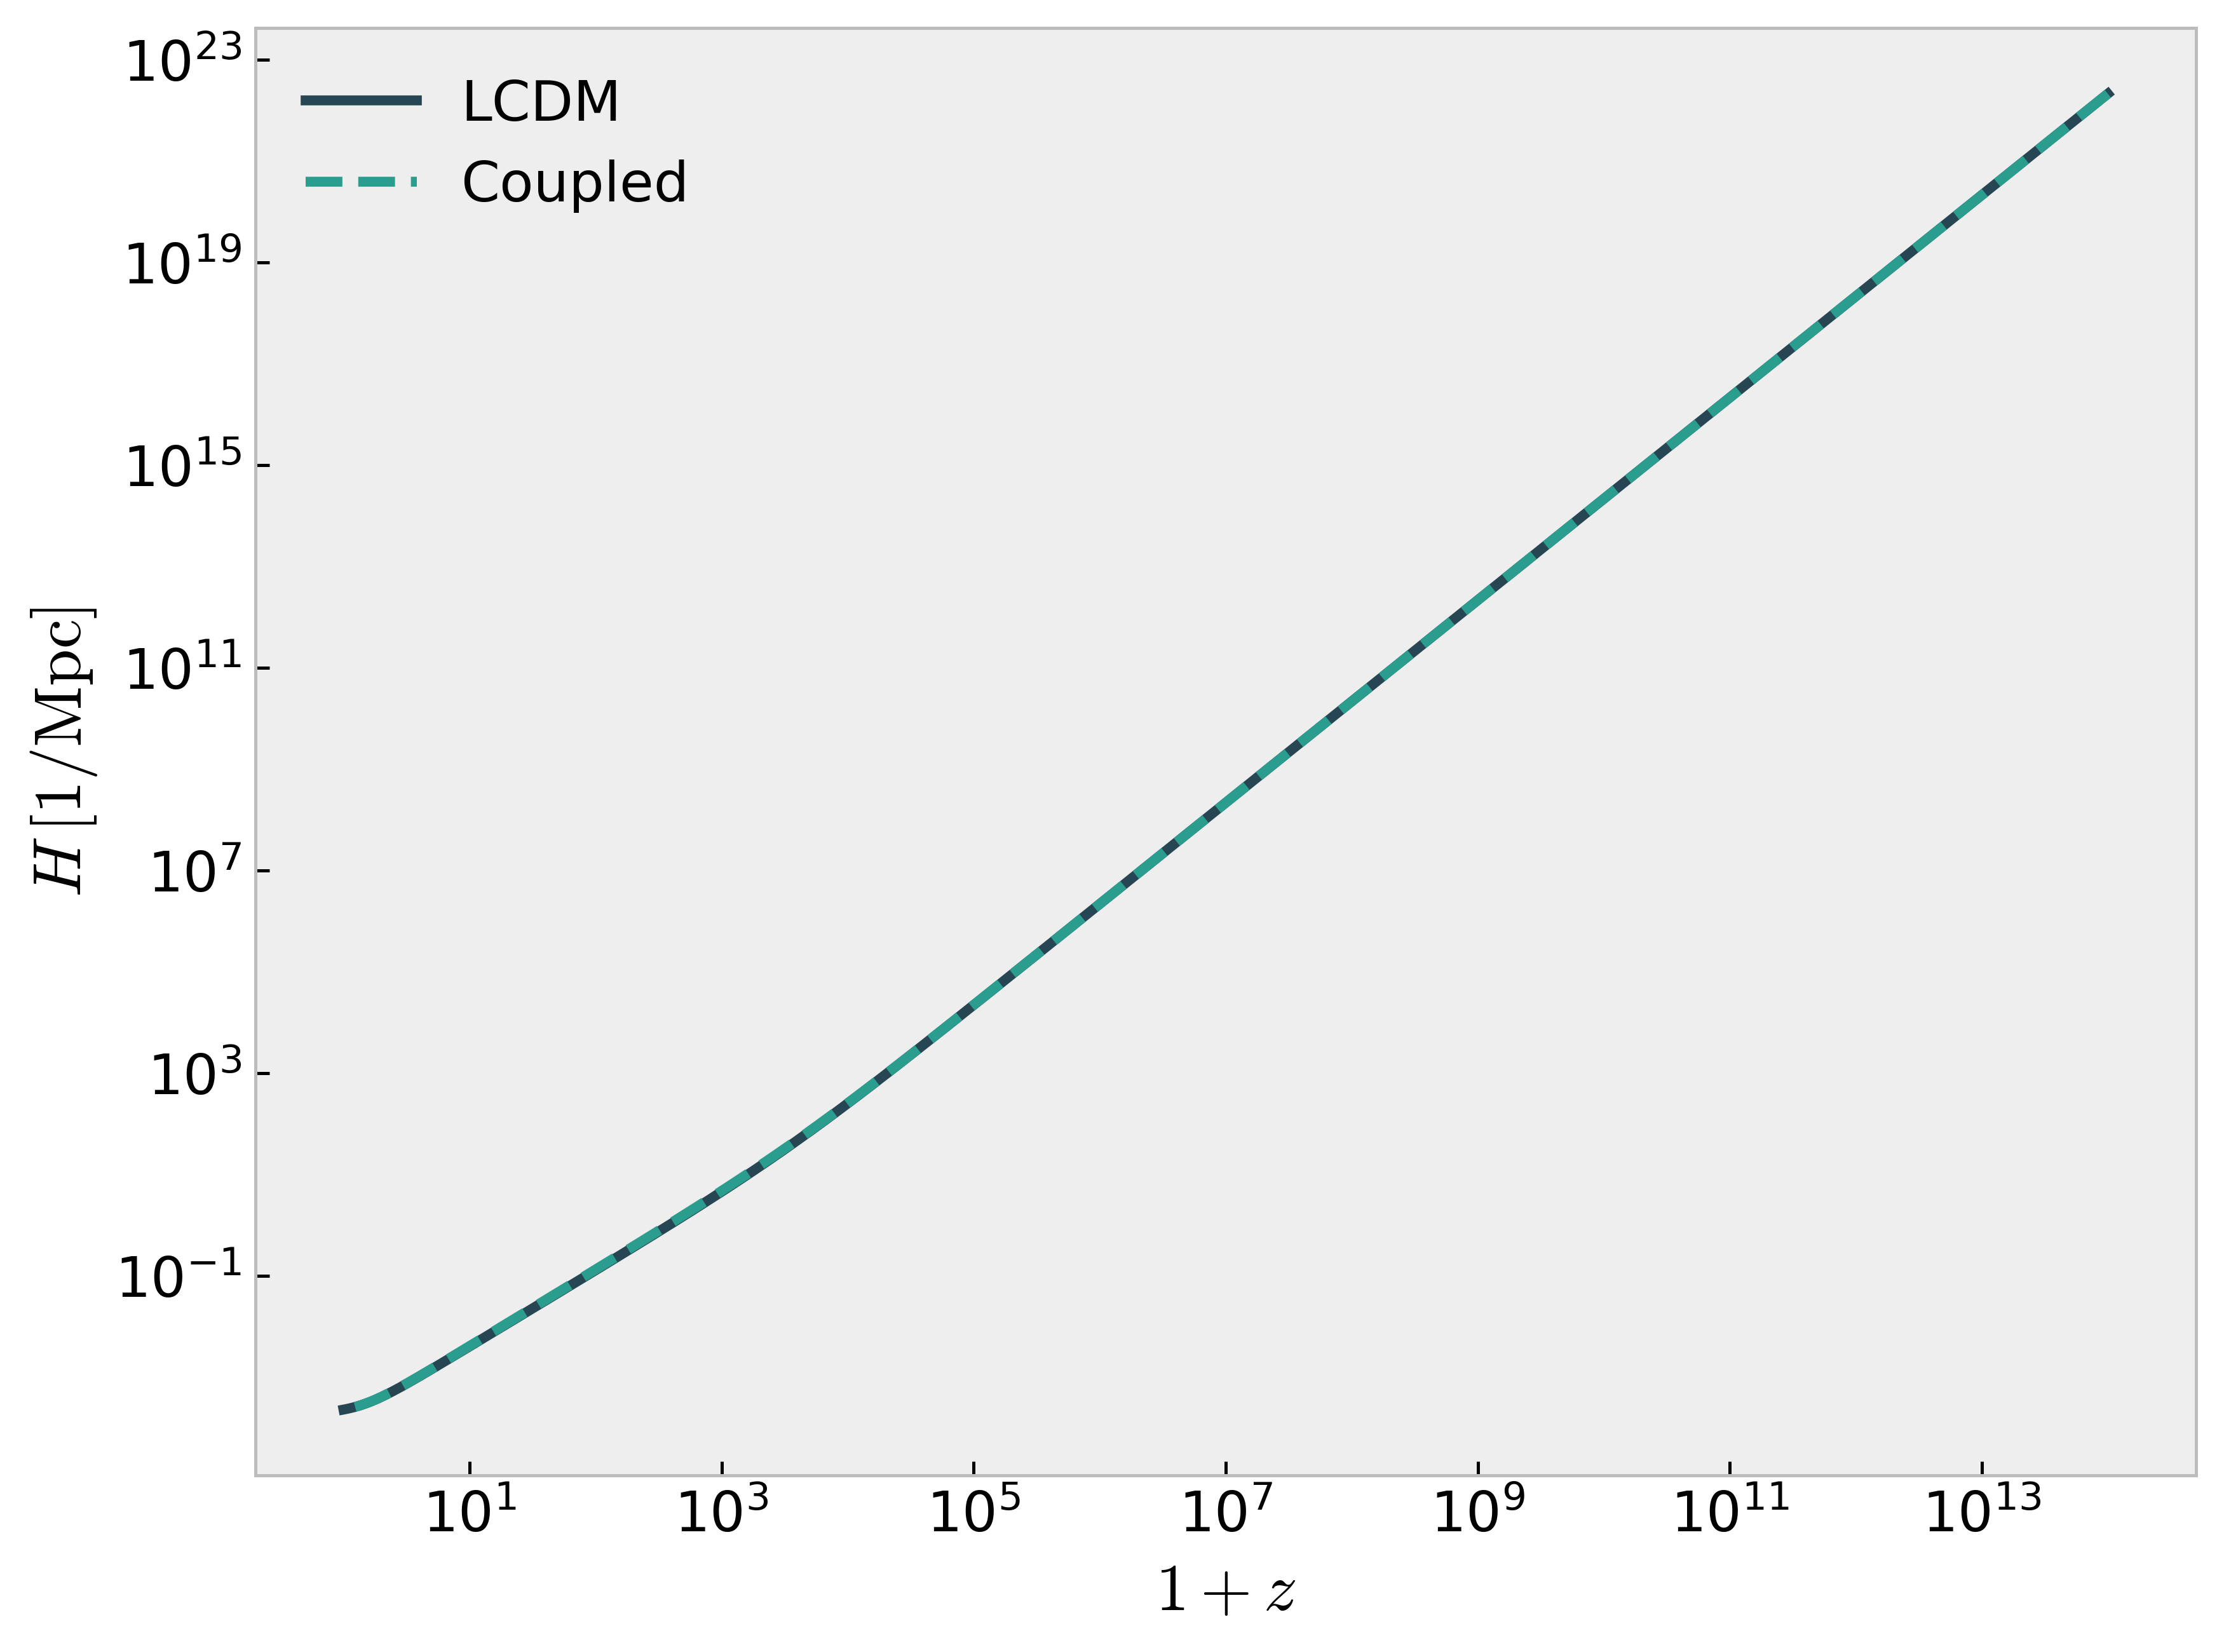

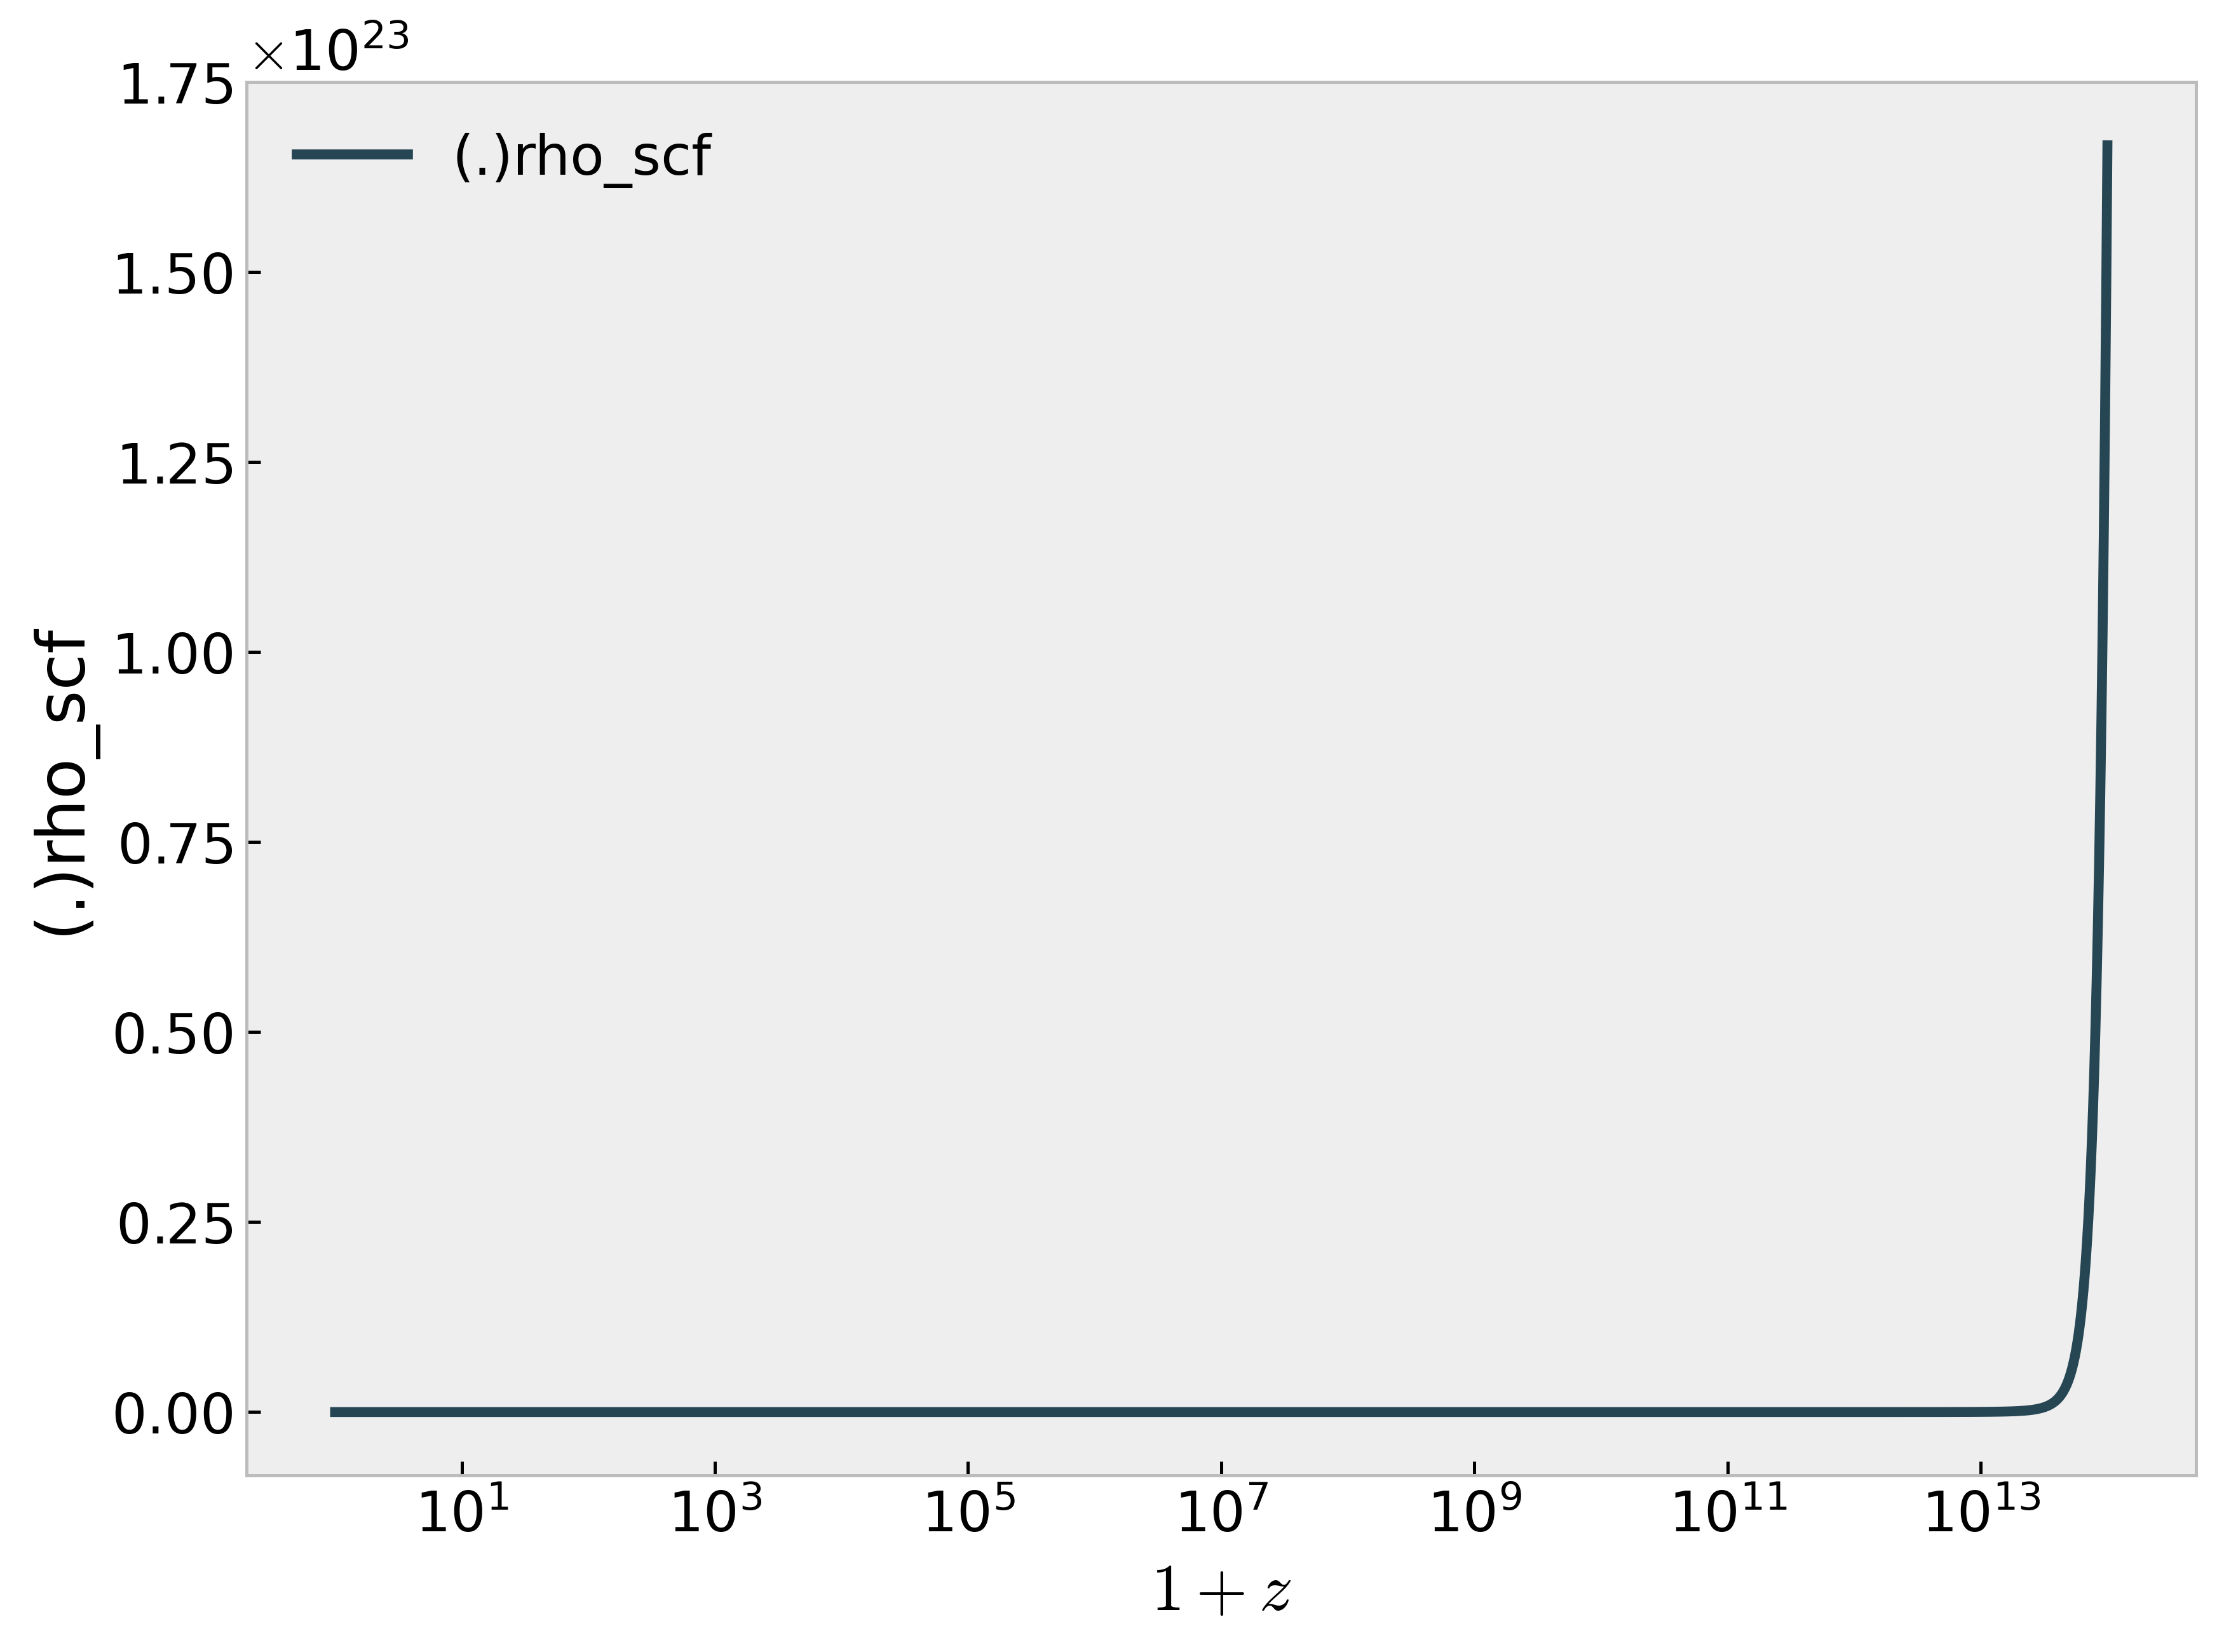

In [ ]:
bg_lcdm = lcdm.get_background()
bg_coup = coup.get_background()

# helper to find available background fields

def get_bg_field(bg, keys):
    for k in keys:
        if k in bg:
            return bg[k], k
    return None, None

z = bg_coup['z']

# H(z)
plt.figure(figsize=(8, 6))
plt.loglog(1+z, bg_lcdm['H [1/Mpc]'], lw=lw, ls='-', label='LCDM')
plt.loglog(1+z, bg_coup['H [1/Mpc]'], lw=lw, ls='--', label='Coupled')
plt.xlabel(r'$1+z$')
plt.ylabel(r'$H\,[1/\mathrm{Mpc}]$')
plt.legend()
plt.tight_layout()

# Omega_scf or rho_scf (depending on output keys)
plt.figure(figsize=(8, 6))
vals, label = get_bg_field(bg_coup, ['Omega_scf', '(.)Omega_scf', '(.)rho_scf'])
if vals is not None:
    plt.semilogx(1+z, vals, lw=lw, ls='-', label=label)
    plt.xlabel(r'$1+z$')
    plt.ylabel(label)
    plt.legend()
    plt.tight_layout()
else:
    print('No SCF background field found (keys may differ).')


## 5) CMB spectra


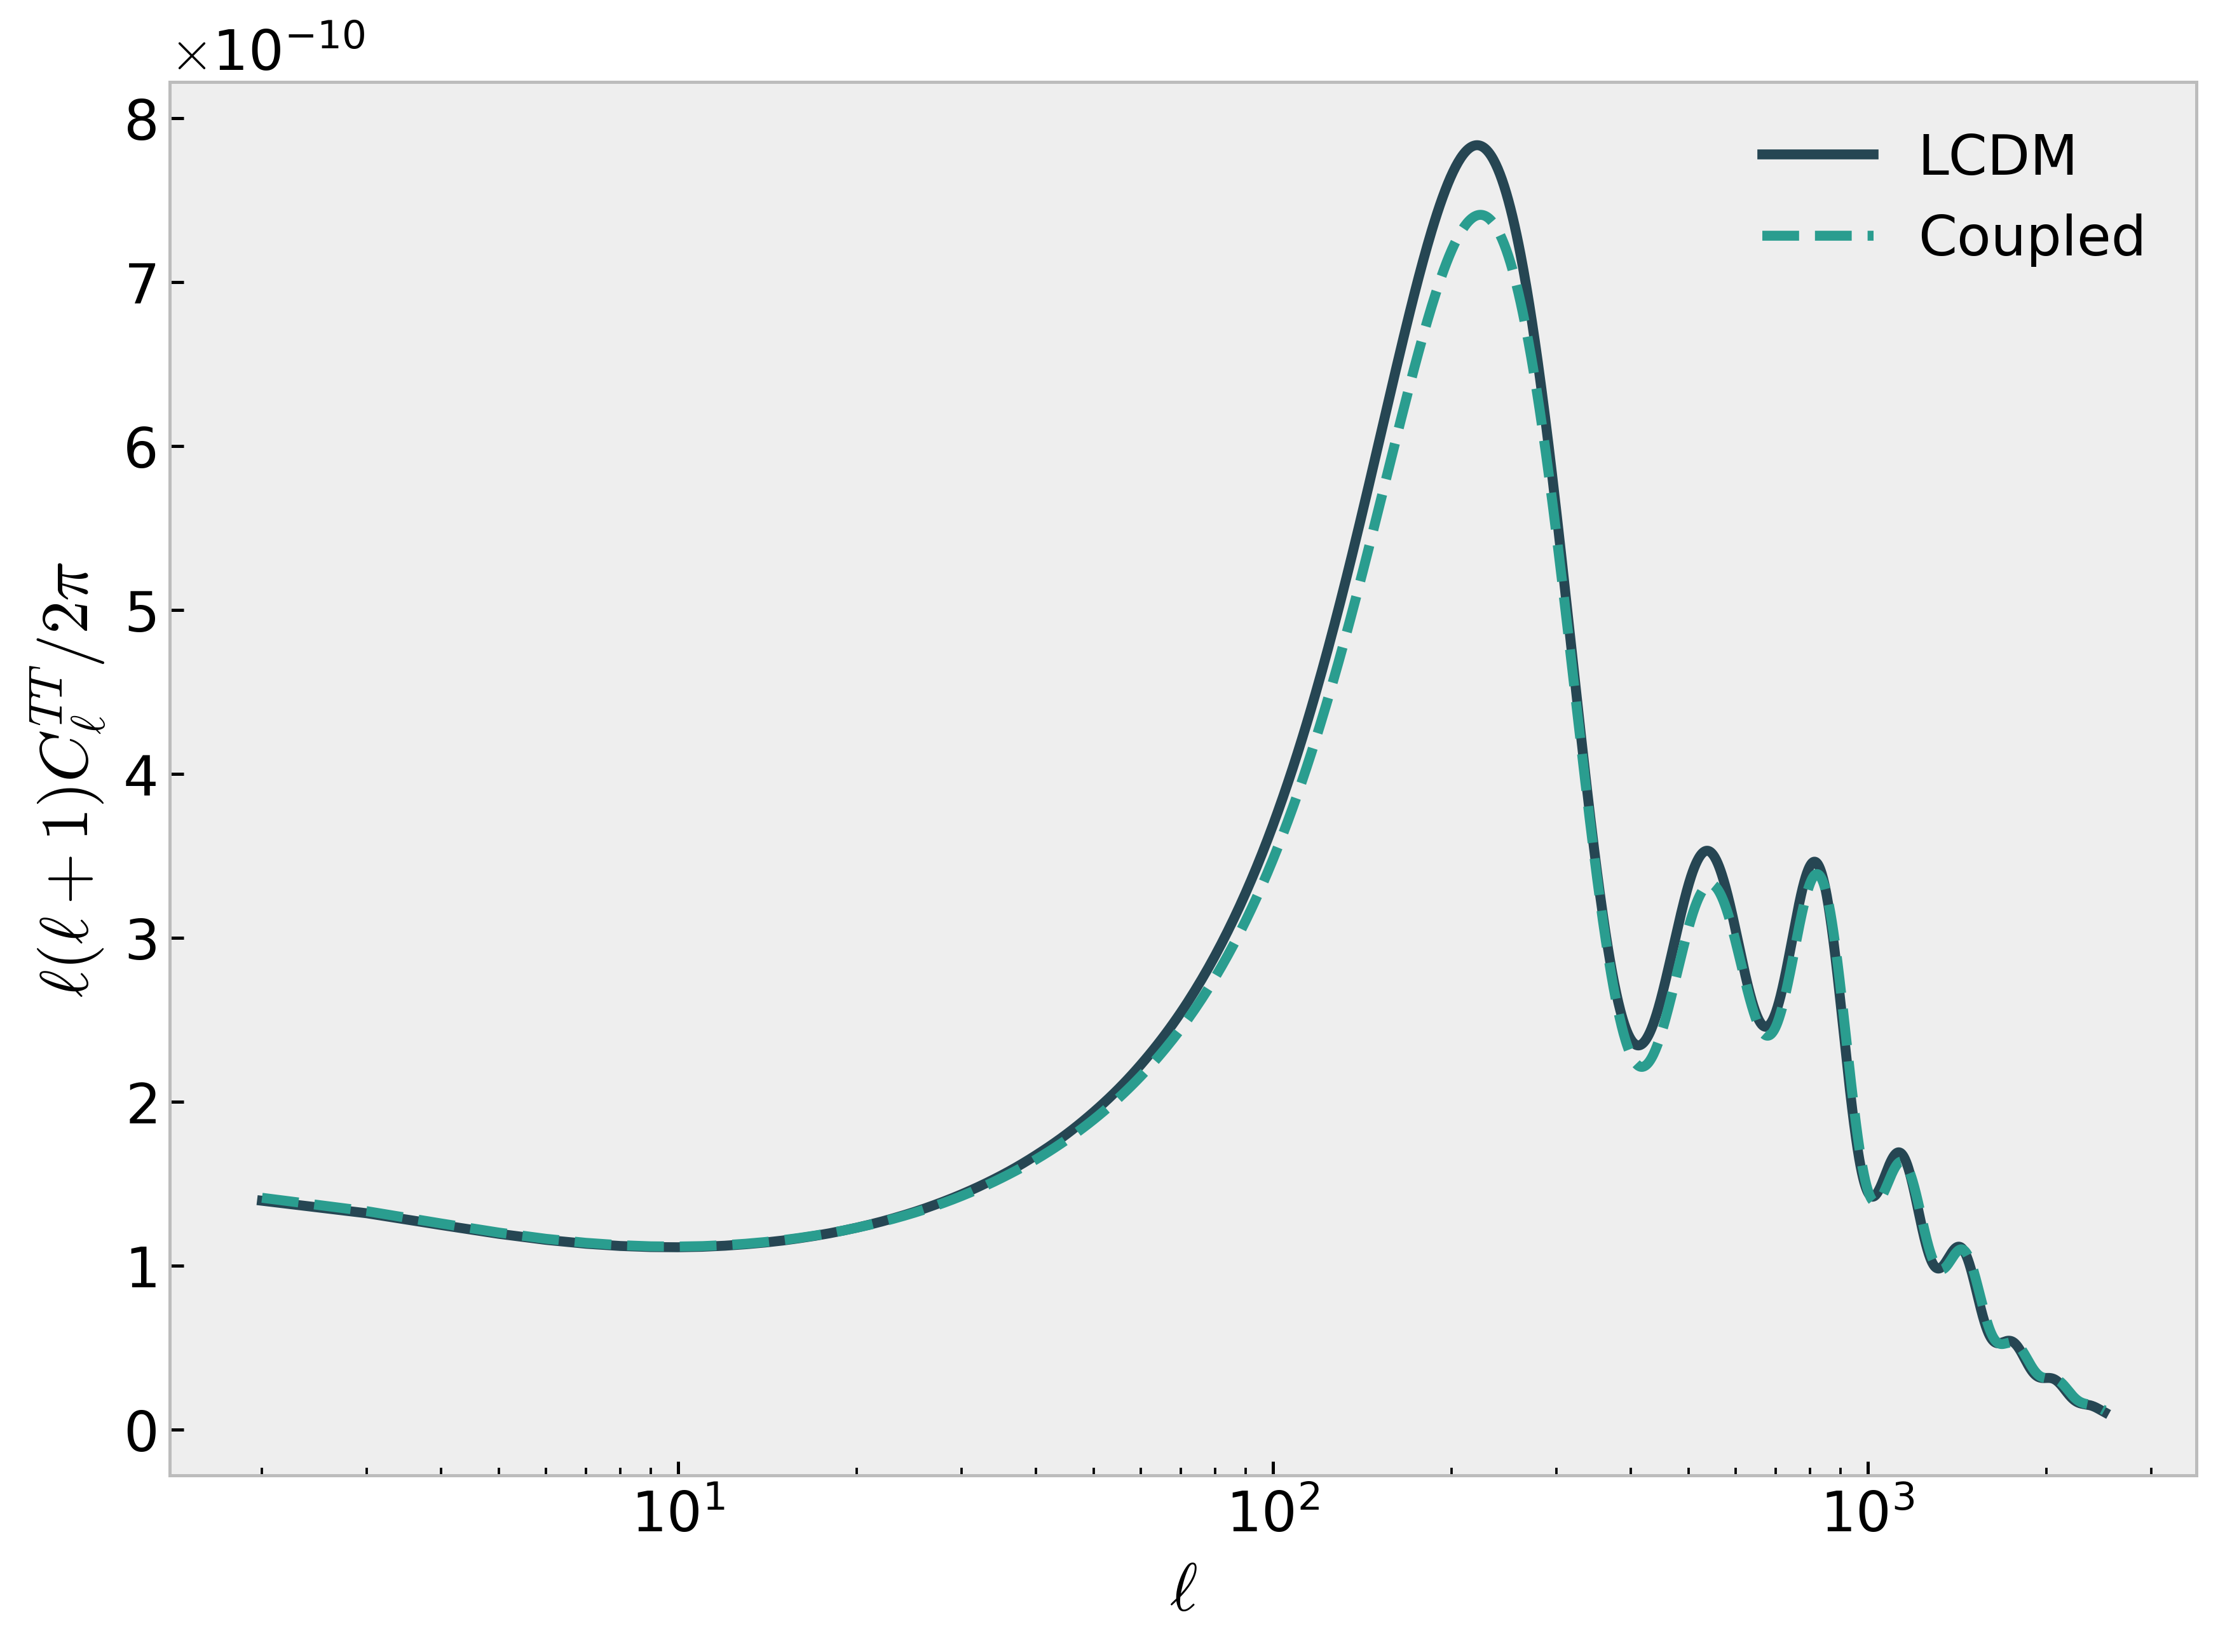

In [ ]:
cls_lcdm = lcdm.lensed_cl(2500)
cls_coup = coup.lensed_cl(2500)

ell = cls_lcdm['ell'][2:]
cltt_lcdm = cls_lcdm['tt'][2:]
cltt_coup = cls_coup['tt'][2:]

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.plot(ell, cltt_lcdm*ell*(ell+1)/(2*np.pi), lw=lw, ls='-', label='LCDM')
plt.plot(ell, cltt_coup*ell*(ell+1)/(2*np.pi), lw=lw, ls='--', label='Coupled')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$')
plt.legend()
plt.tight_layout()


## 6) Matter power spectrum


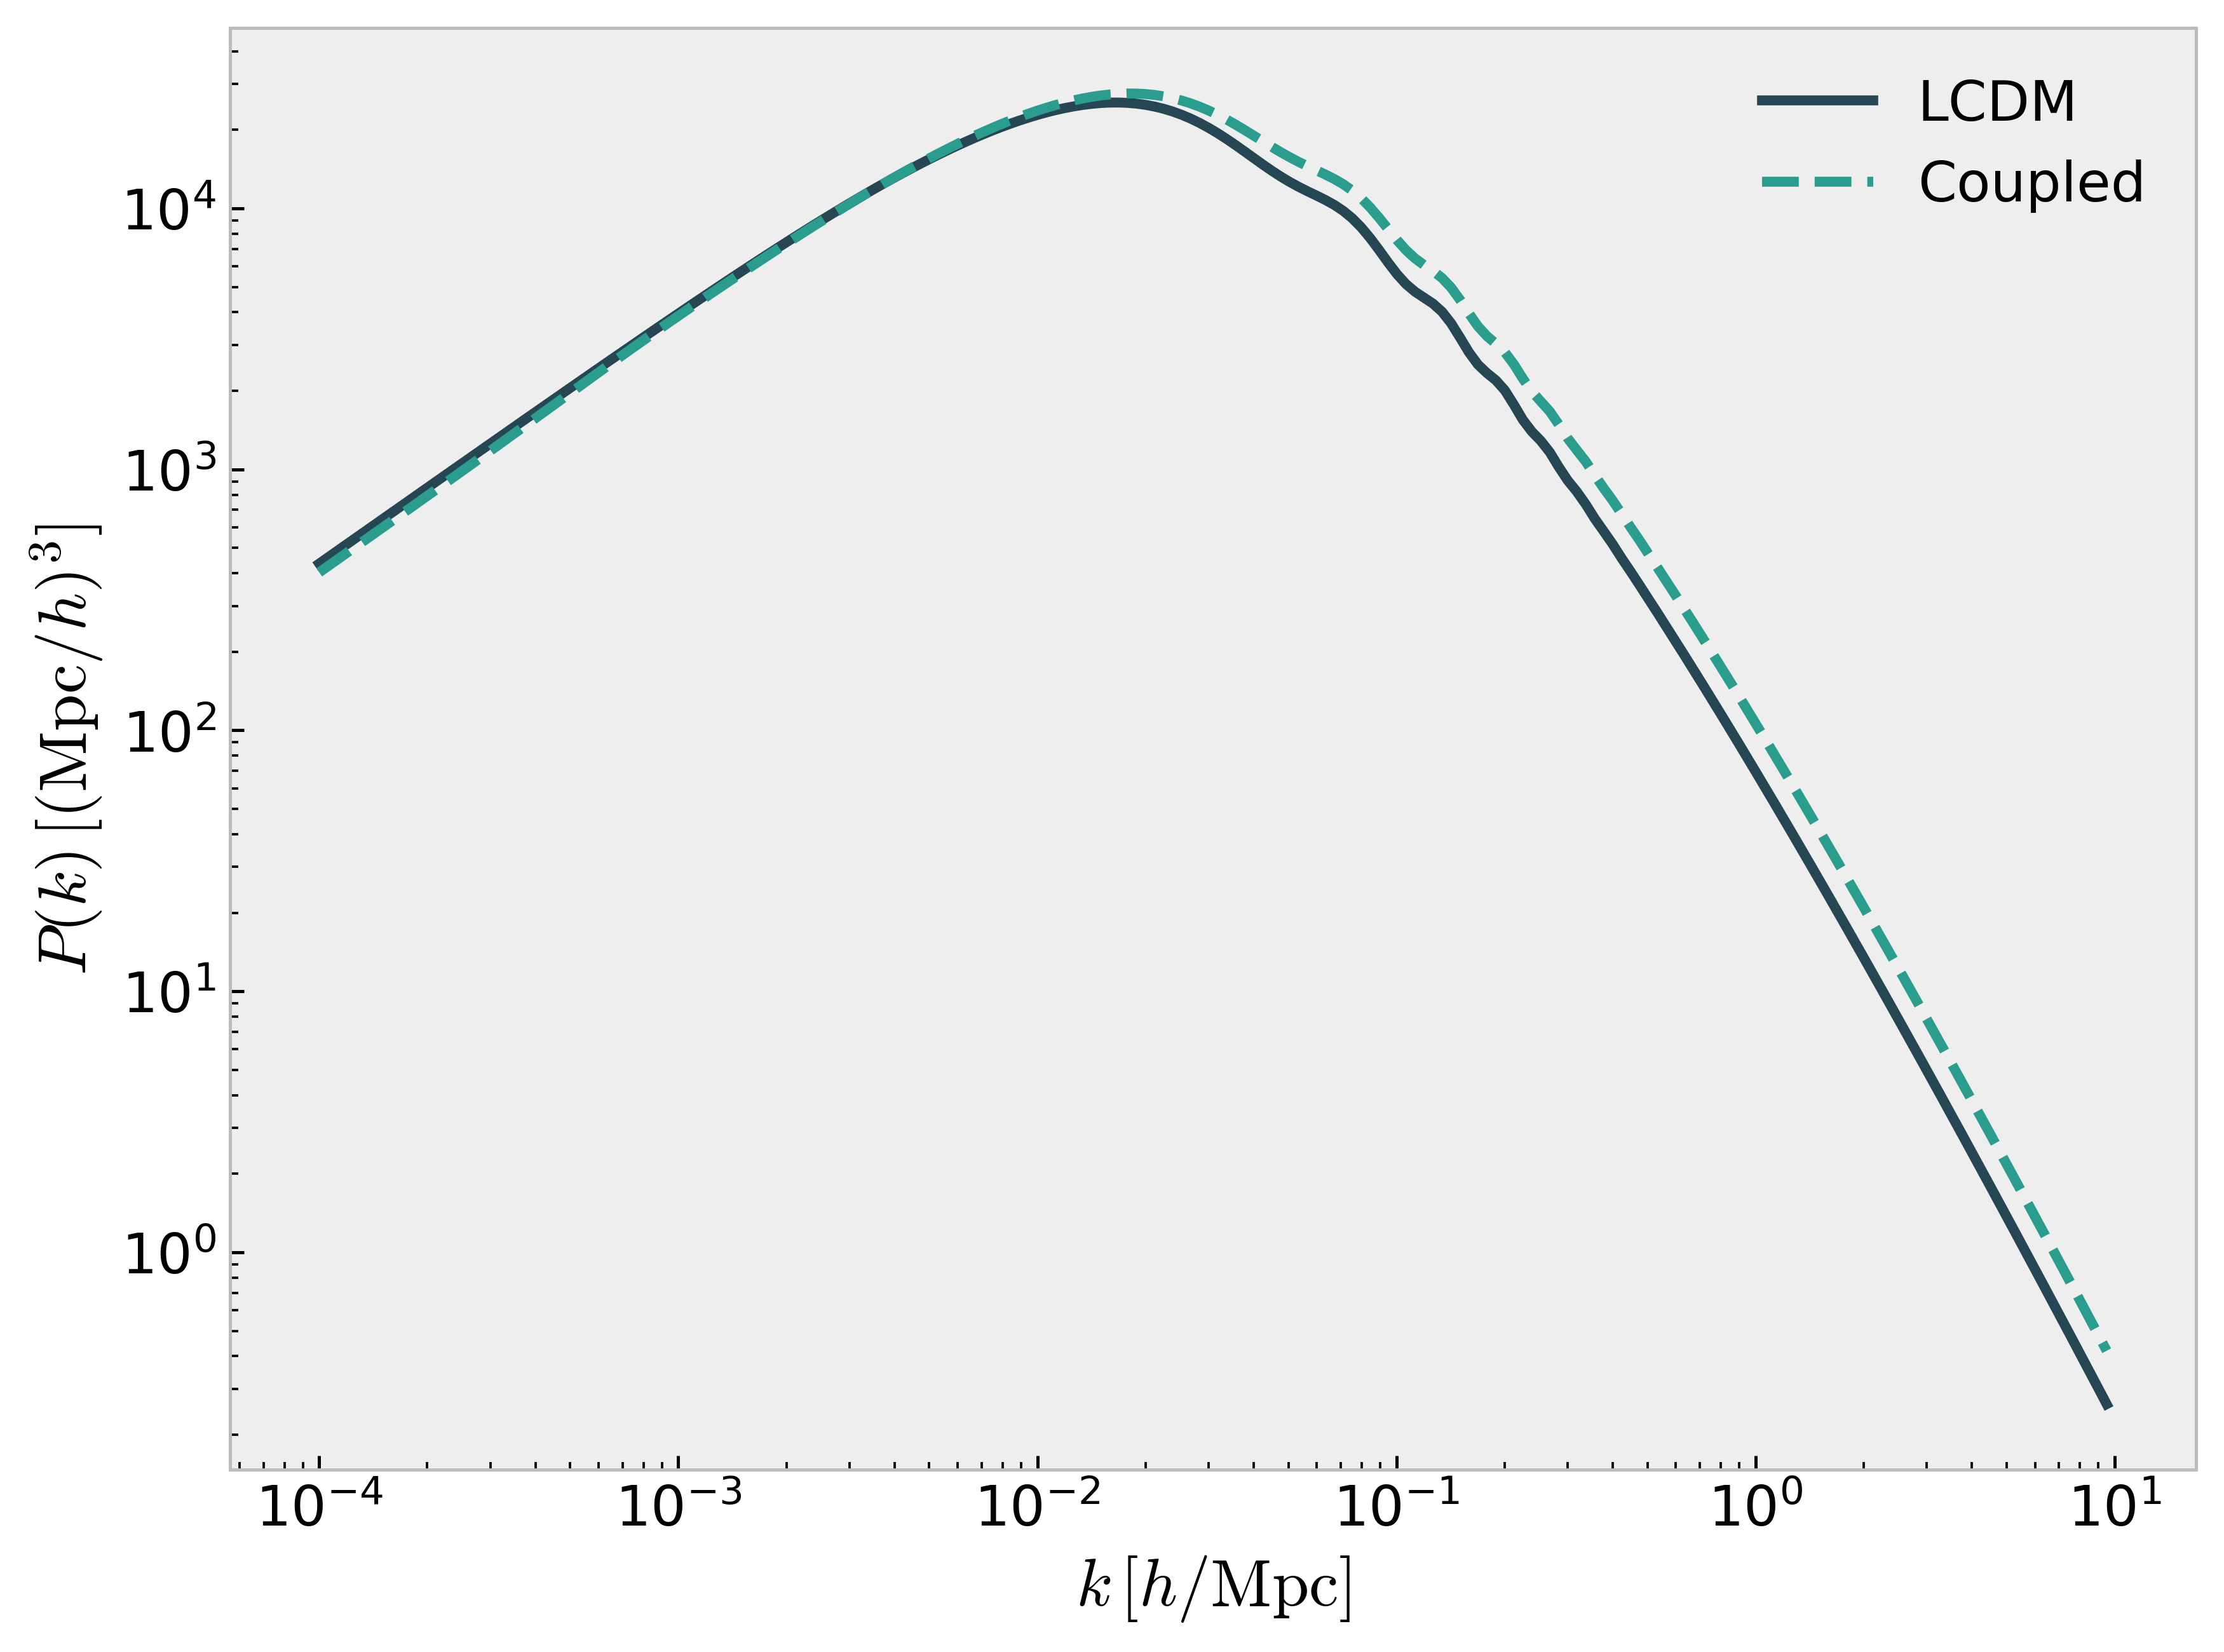

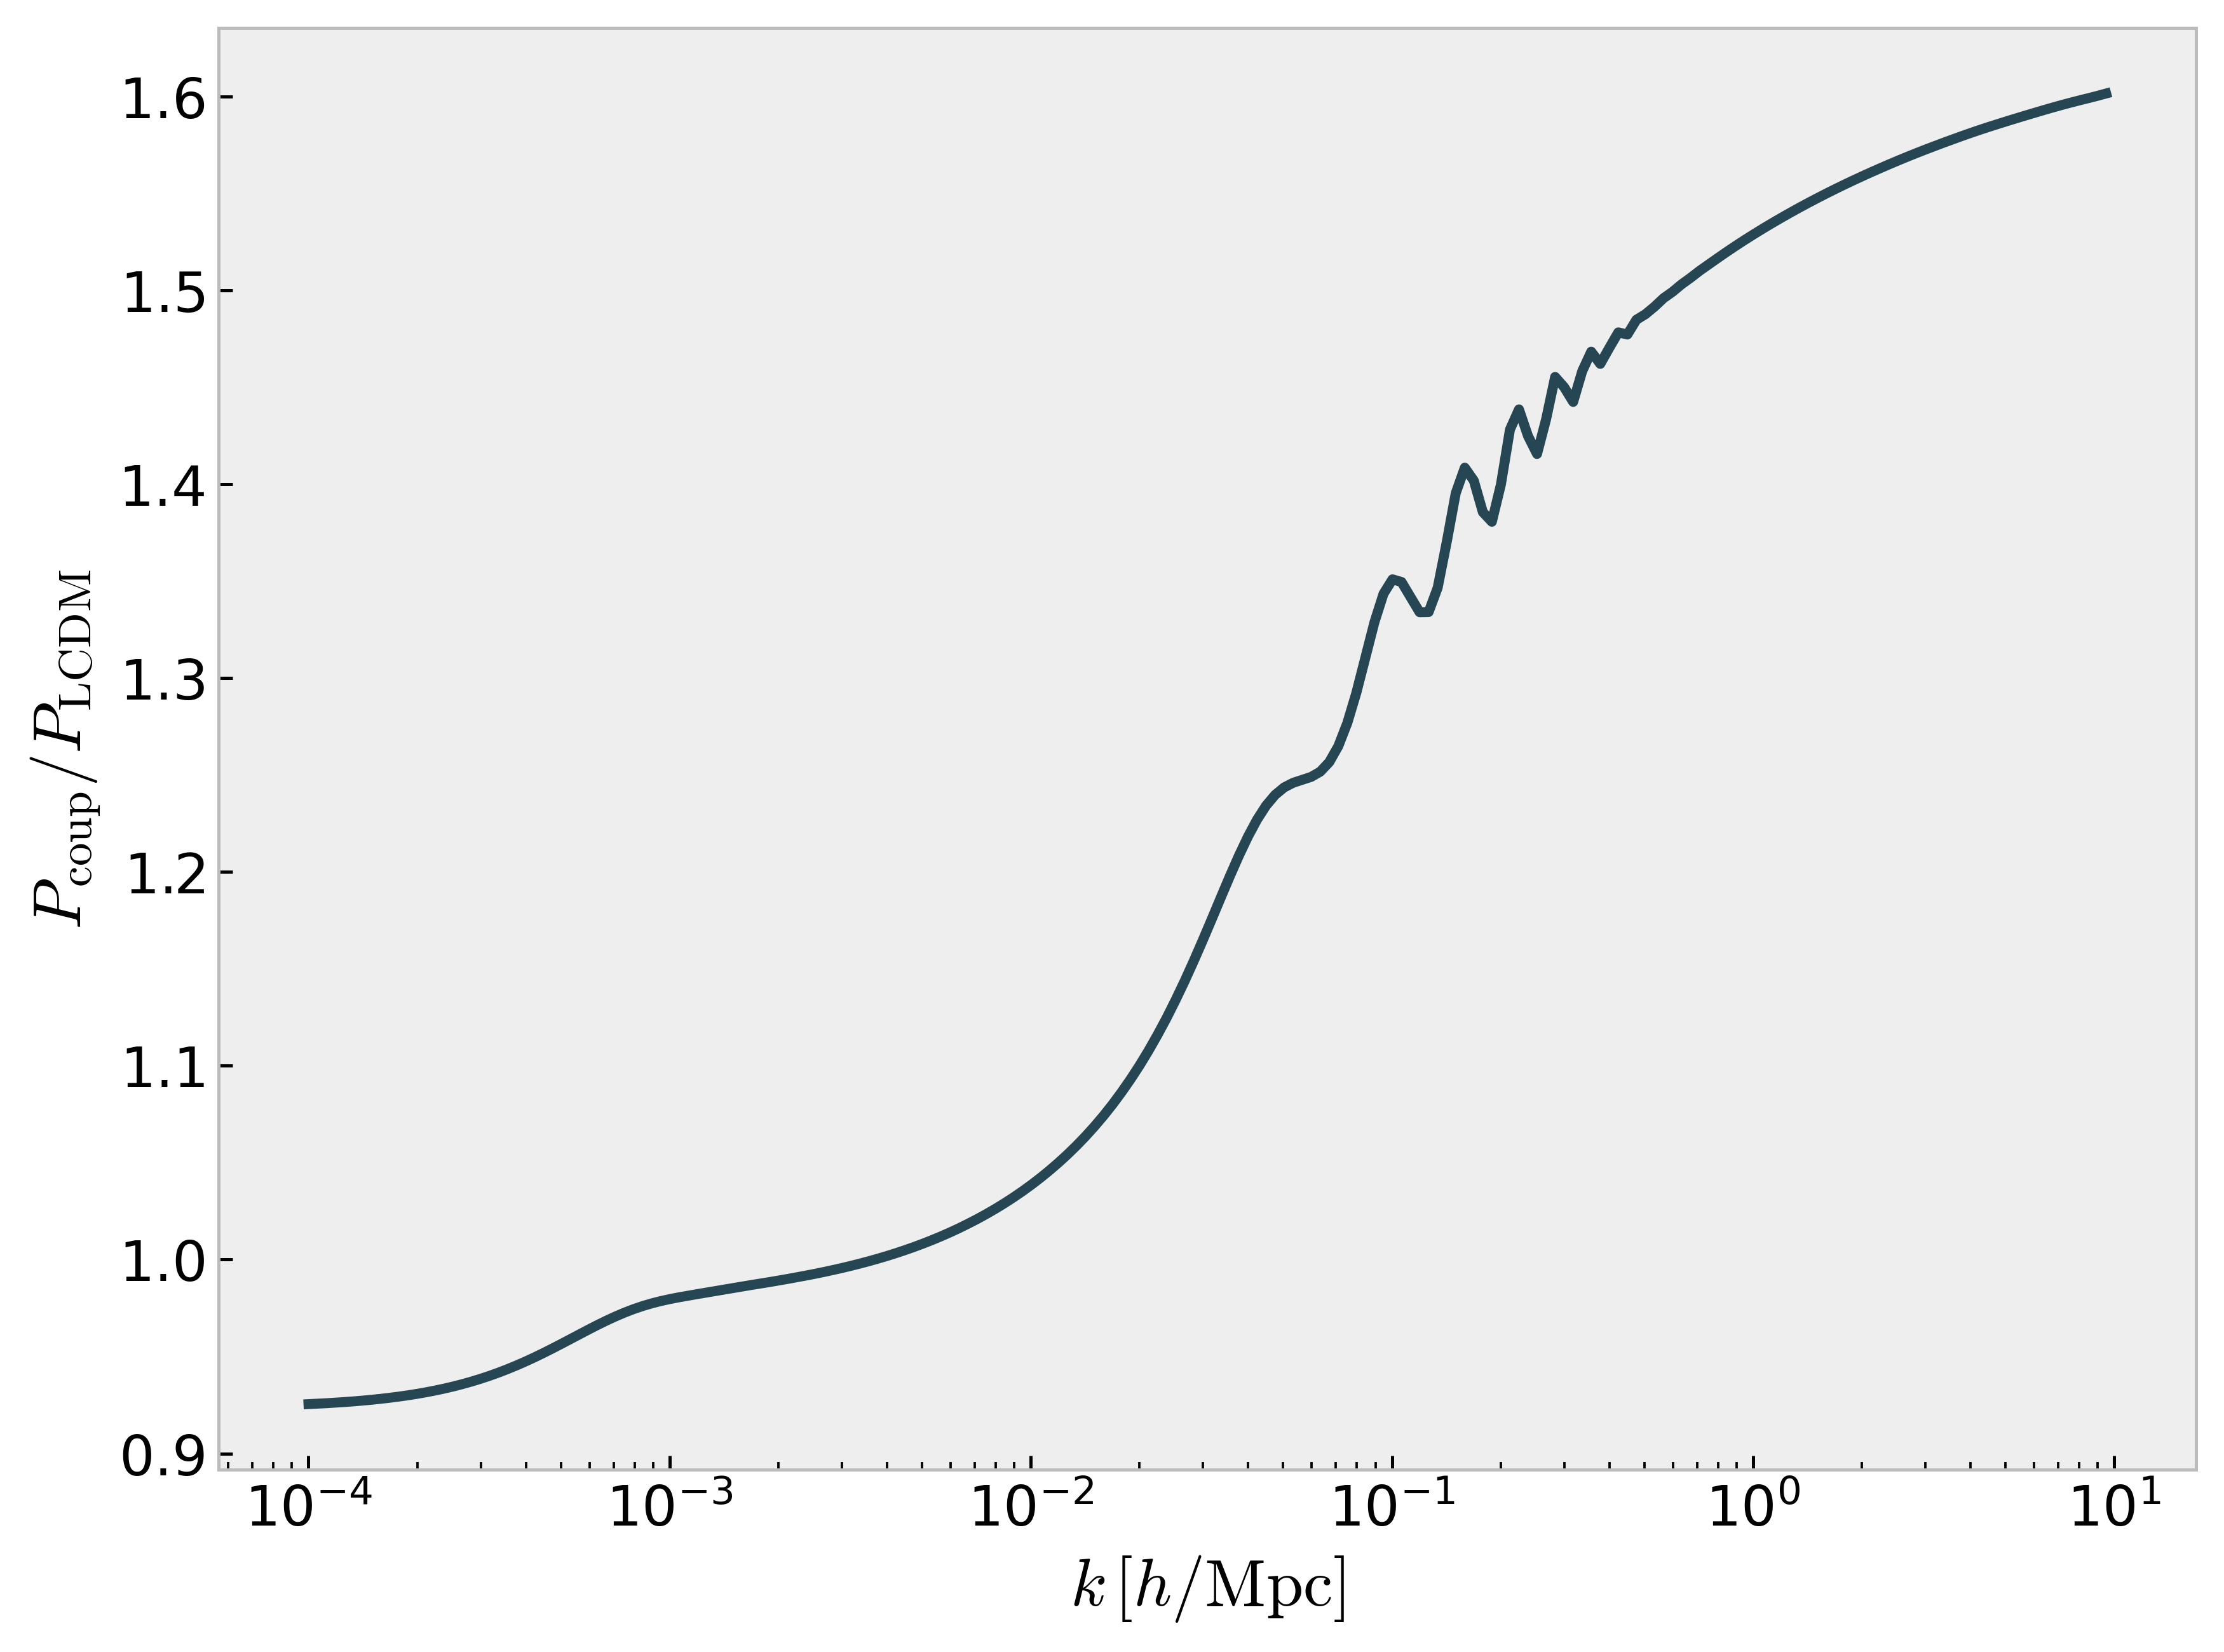

In [ ]:
# k in h/Mpc, convert to 1/Mpc for CLASS
k_max = common['P_k_max_h/Mpc'] * 0.95
k = np.logspace(-4, np.log10(k_max), 200)
h = common['h']

pk_lcdm = np.array([lcdm.pk(ki*h, 0.0) * h**3 for ki in k])
pk_coup = np.array([coup.pk(ki*h, 0.0) * h**3 for ki in k])

plt.figure(figsize=(8, 6))
plt.loglog(k, pk_lcdm, lw=lw, ls='-', label='LCDM')
plt.loglog(k, pk_coup, lw=lw, ls='--', label='Coupled')
plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k)\,[\mathrm{(Mpc}/h)^3]$')
plt.legend()
plt.tight_layout()

# Ratio
plt.figure(figsize=(8, 6))
plt.semilogx(k, pk_coup/pk_lcdm, lw=lw, ls='-')
plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P_{\rm coup}/P_{\rm LCDM}$')
plt.tight_layout()


## 7) Perturbations (example)


pert type: <class 'dict'>
pert keys: ['scalar']


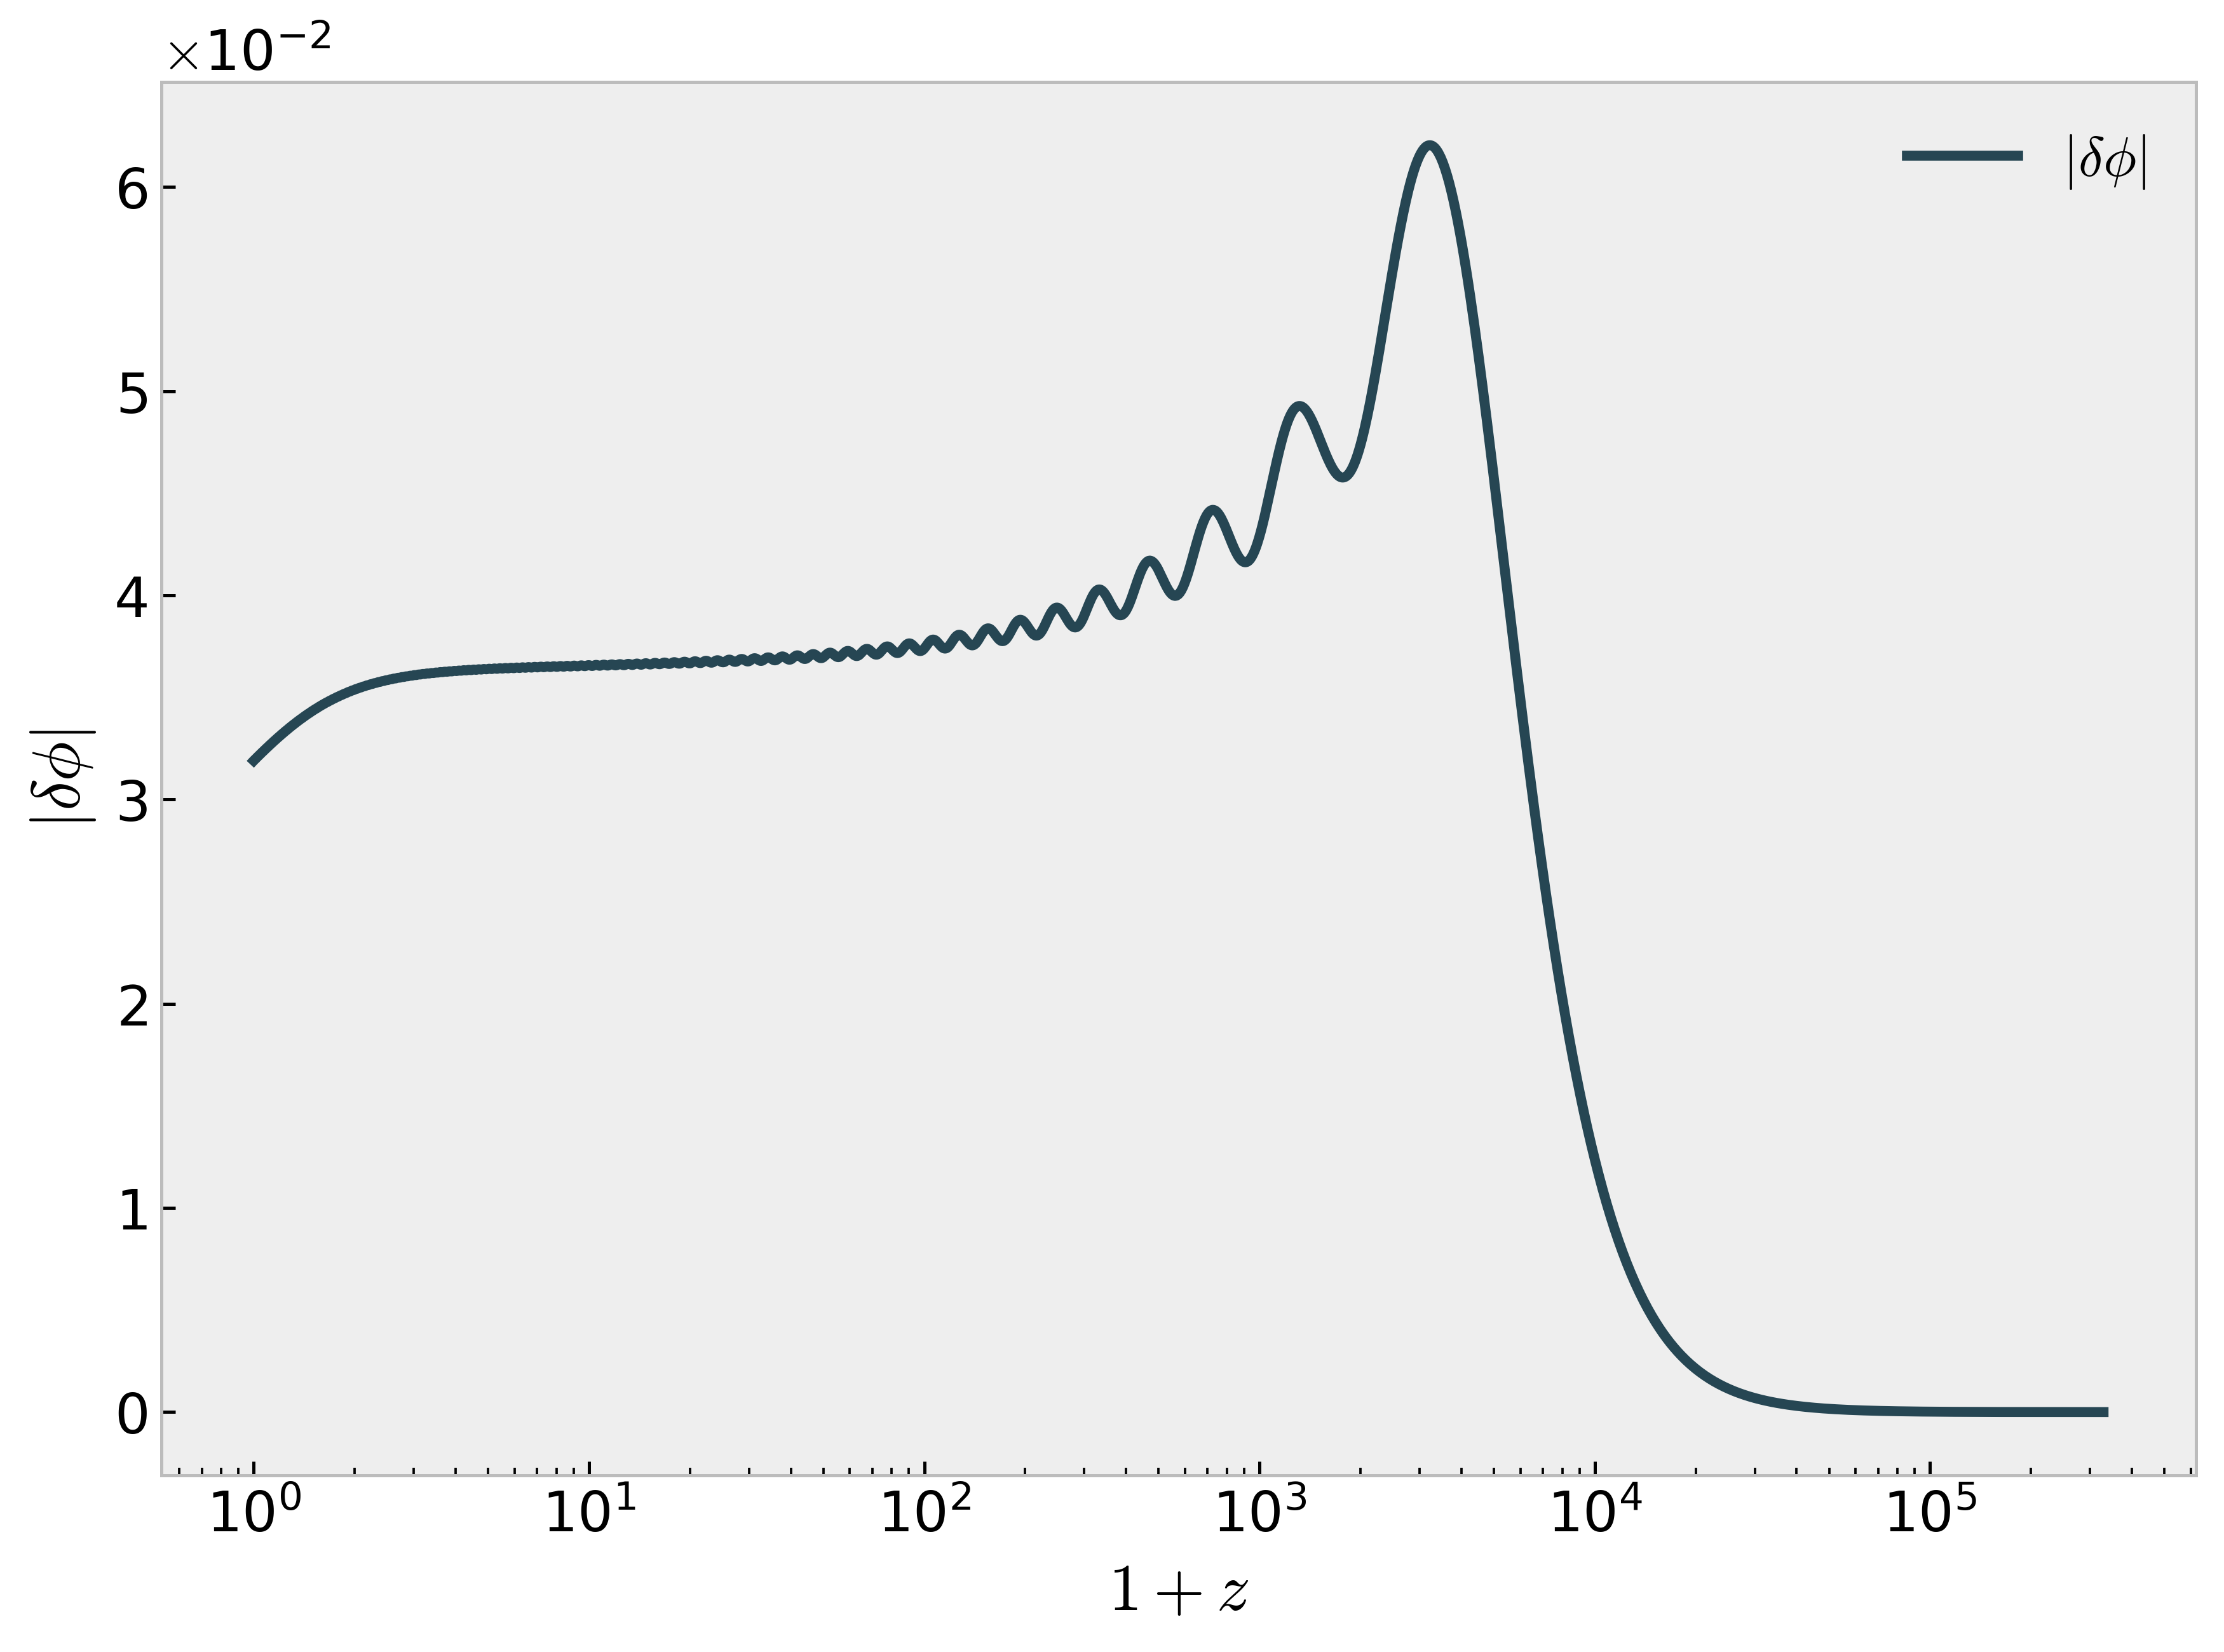

In [ ]:
pert = coup.get_perturbations()

# inspect available keys
print('pert type:', type(pert))
if hasattr(pert, 'keys'):
    print('pert keys:', list(pert.keys()))

# pick the first k-mode in a robust way
p = None
if isinstance(pert, dict):
    if 'scalar' in pert:
        p = pert['scalar'][0]
    elif 'scalars' in pert:
        p = pert['scalars'][0]
elif isinstance(pert, list) and len(pert) > 0:
    p = pert[0]

if p is None:
    print('No scalar perturbations found. Set k_output_values to store perturbations.')
else:
    a = p['a']
    z = 1/a - 1

    plt.figure(figsize=(8, 6))
    if 'delta_phi_scf' in p:
        plt.semilogx(1+z, np.abs(p['delta_phi_scf']), lw=lw, label=r'$|\delta\phi|$')
        plt.xlabel(r'$1+z$')
        plt.ylabel(r'$|\delta\phi|$')
        plt.legend()
        plt.tight_layout()
    else:
        print('No delta_phi_scf field in perturbations output.')


## 9) Disformal case (alpha=1, D0=1)

Same plots as above, but for the disformal coupling with `scf_alpha=1` and `scf_D0=1`.


[3.87968e+09 3.87968e+09 3.87968e+09 ... 3.87968e+09 3.87968e+09
 3.87968e+09]
[-1.06187950e-07 -1.06187950e-07 -1.06187950e-07 ... -1.04884548e-07
 -1.04881223e-07 -1.04877890e-07]


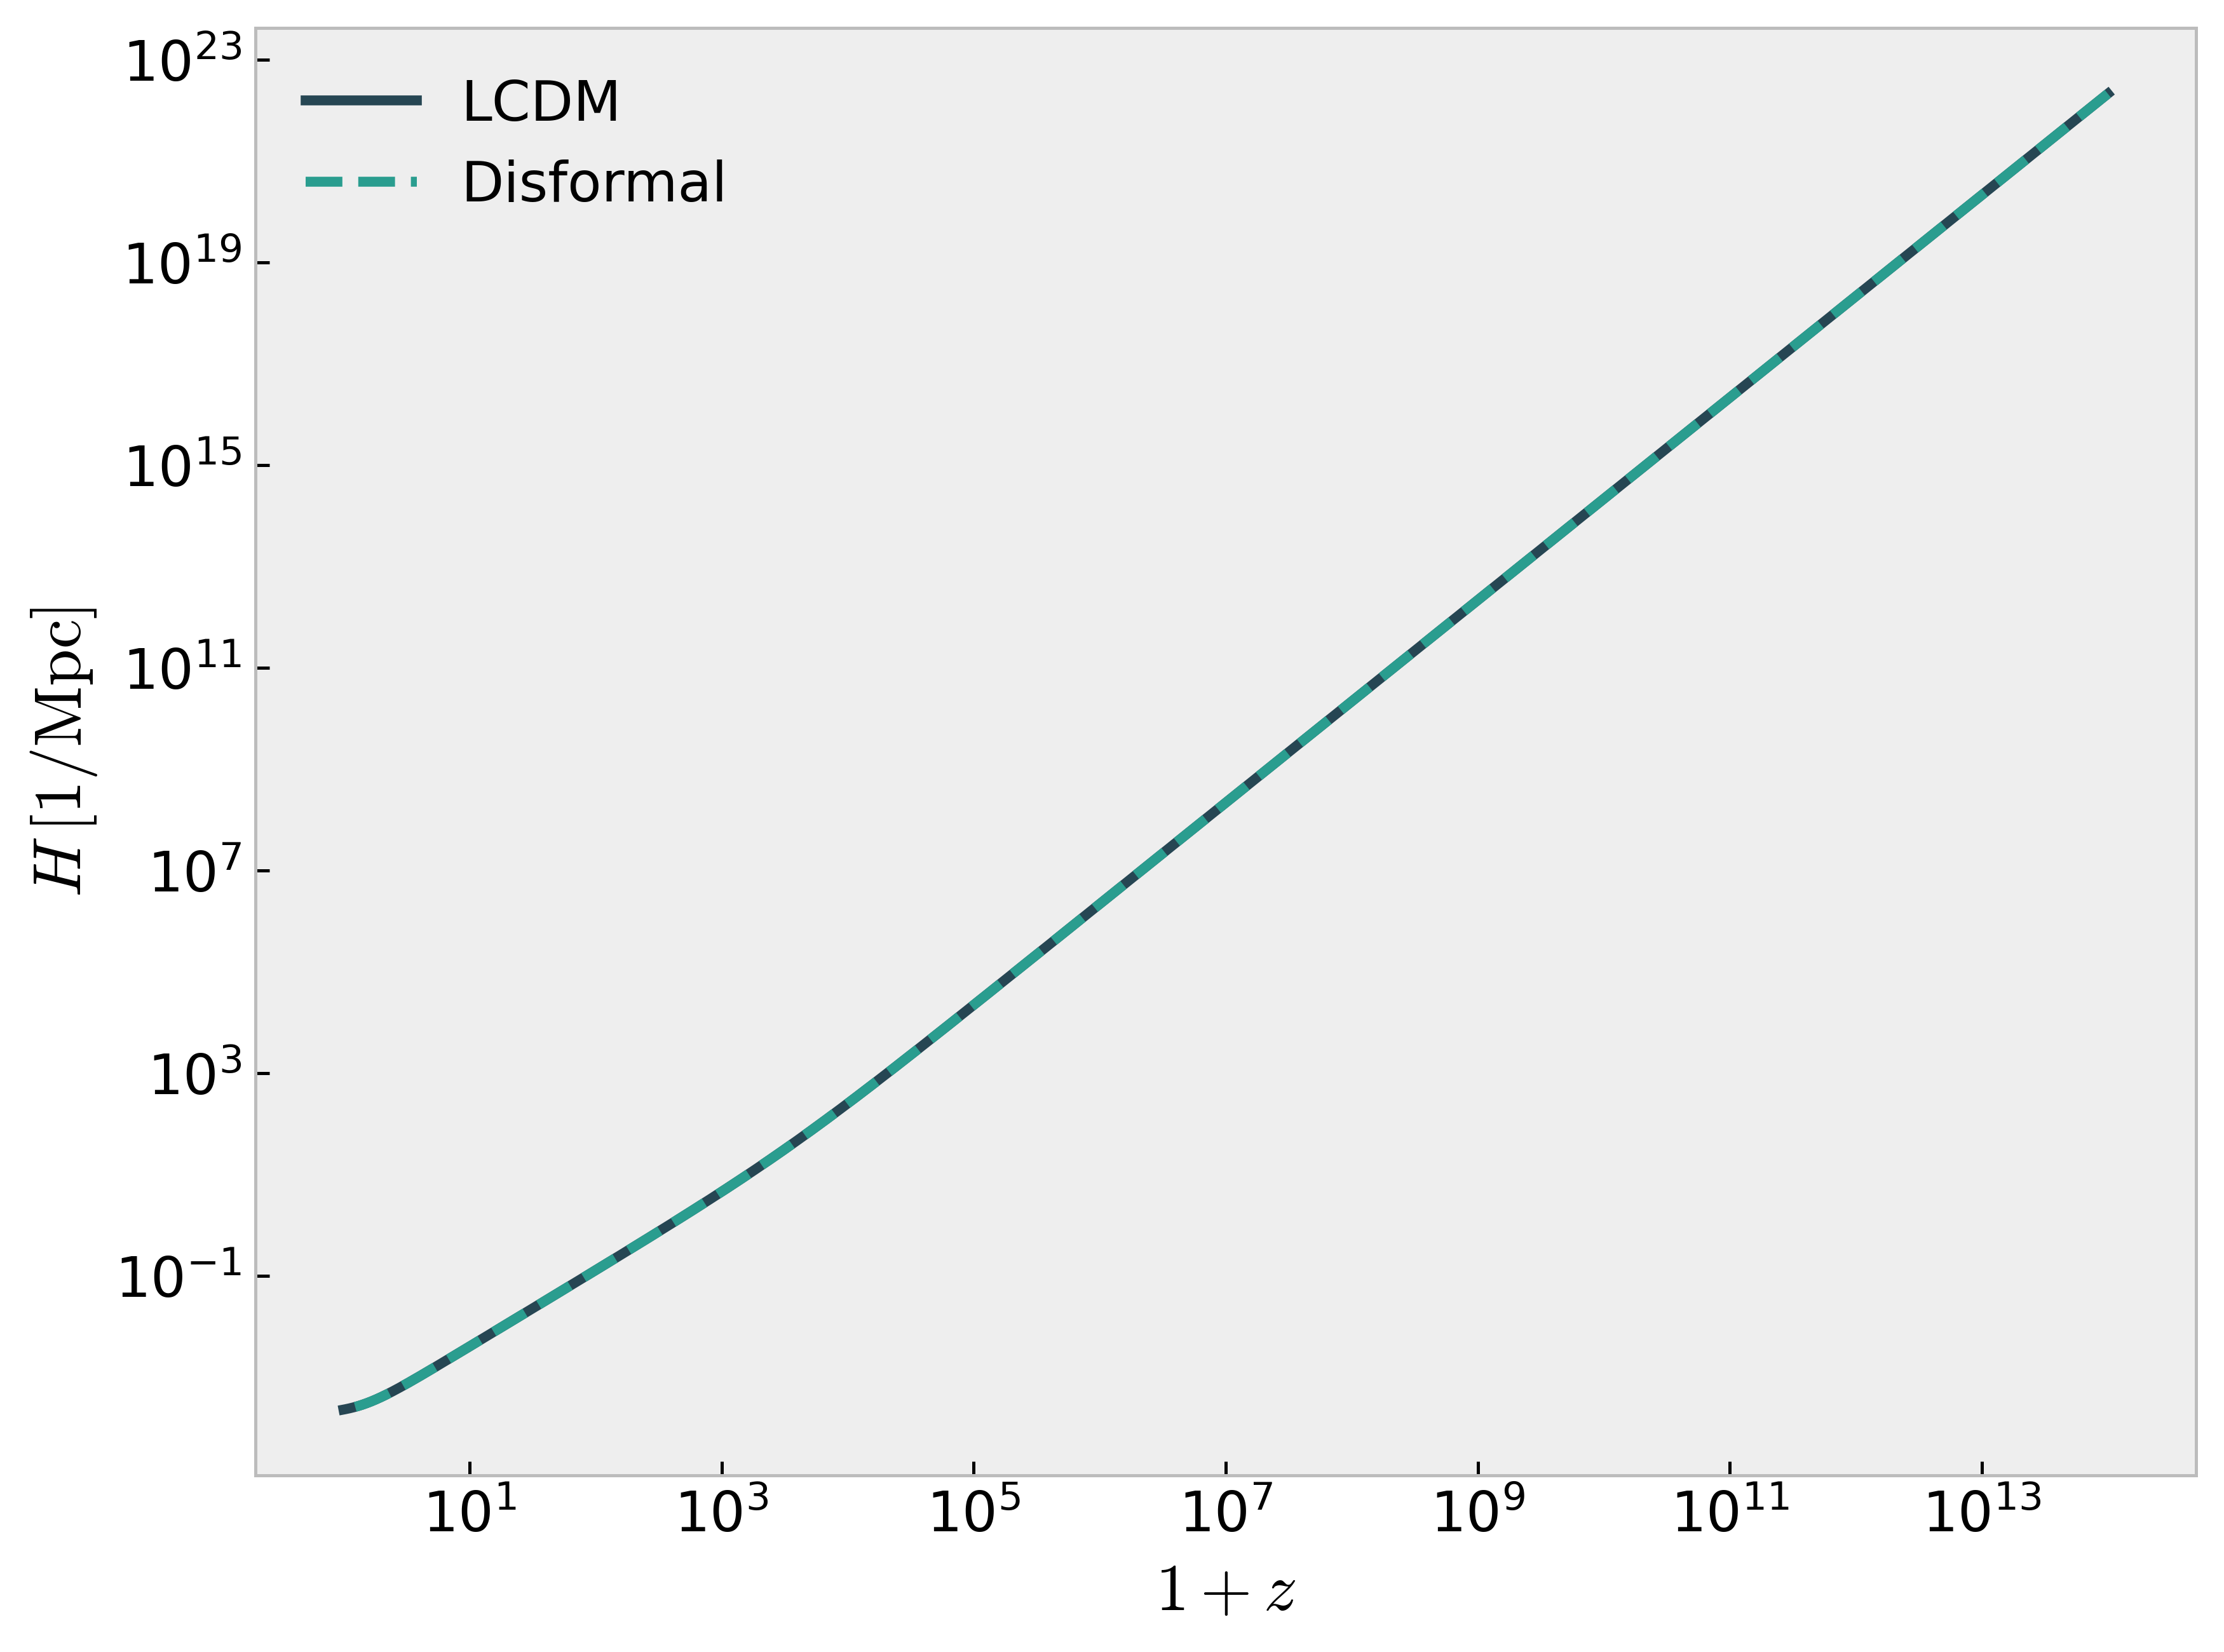

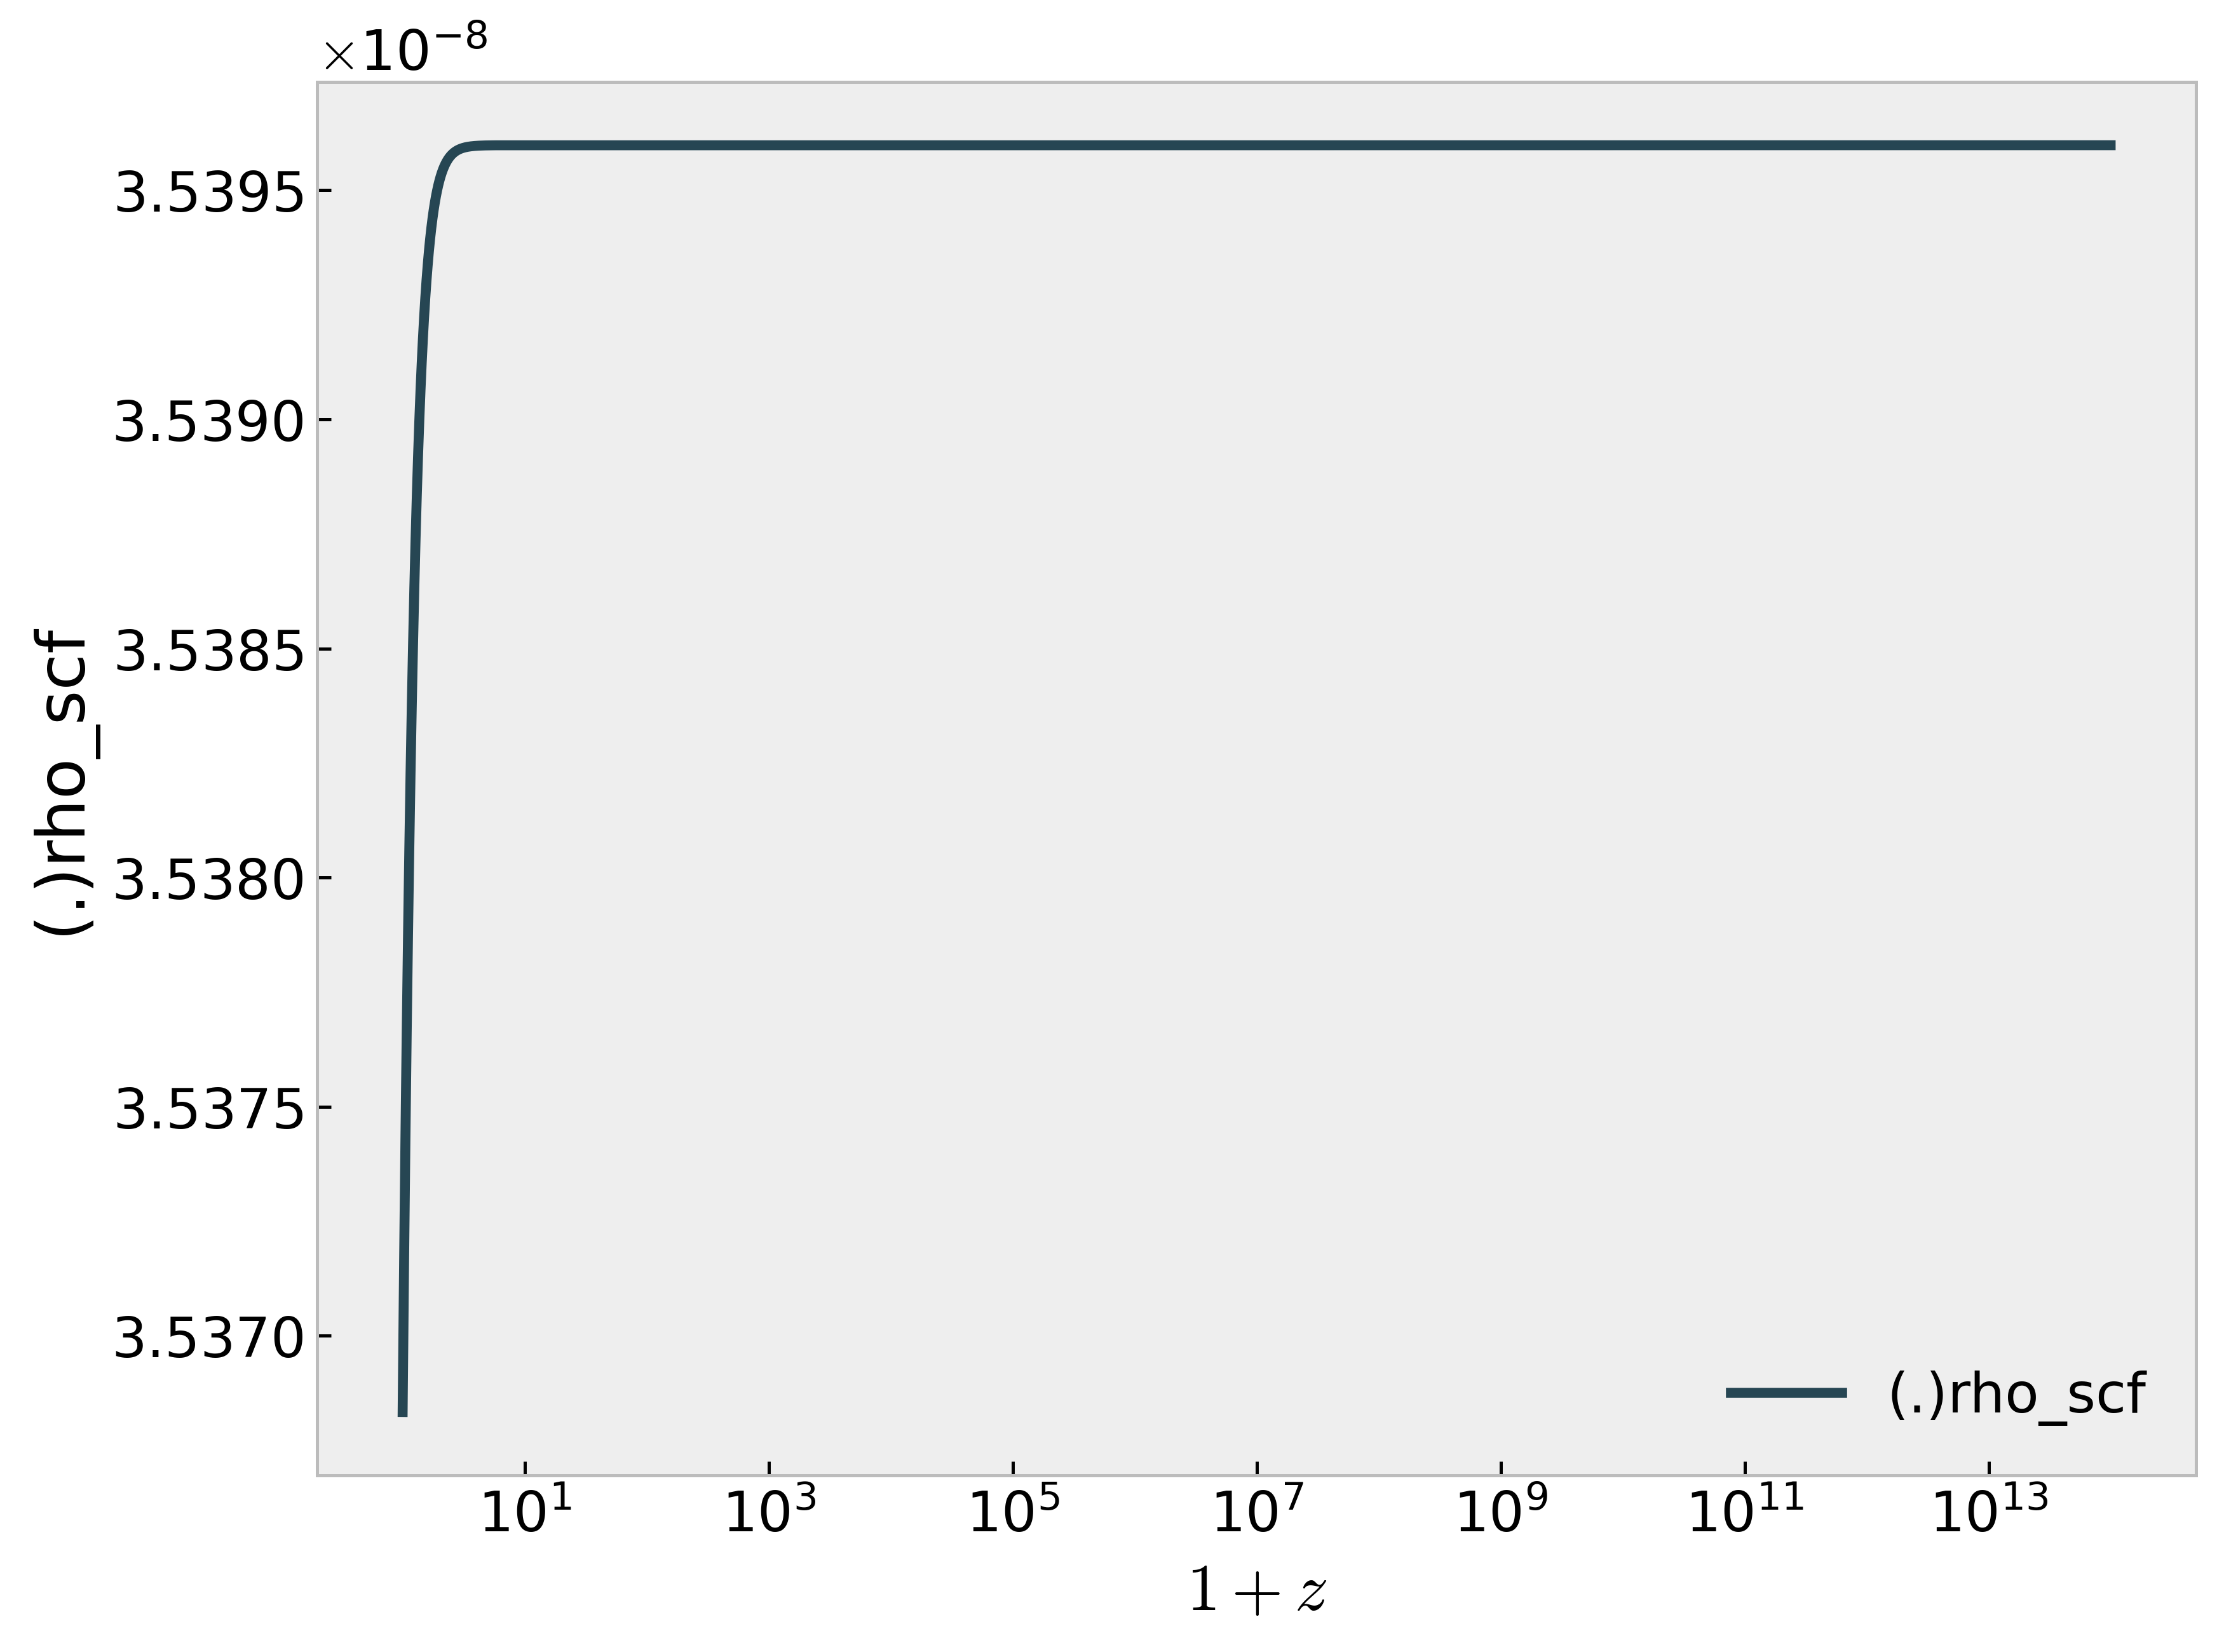

In [ ]:
# Background evolution (LCDM vs disformal)
bg_disf = disf.get_background()
print(bg_disf['D_scf'])
print(bg_disf['Q_scf'])

z = bg_disf['z']

plt.figure(figsize=(8, 6))
plt.loglog(1+z, bg_lcdm['H [1/Mpc]'], lw=lw, ls='-', label='LCDM')
plt.loglog(1+z, bg_disf['H [1/Mpc]'], lw=lw, ls='--', label='Disformal')
plt.xlabel(r'$1+z$')
plt.ylabel(r'$H\,[1/\mathrm{Mpc}]$')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(8, 6))
vals, label = get_bg_field(bg_disf, ['Omega_scf', '(.)Omega_scf', '(.)rho_scf'])
if vals is not None:
    plt.semilogx(1+z, vals, lw=lw, ls='-', label=label)
    plt.xlabel(r'$1+z$')
    plt.ylabel(label)
    plt.legend()
    plt.tight_layout()
else:
    print('No SCF background field found (keys may differ).')


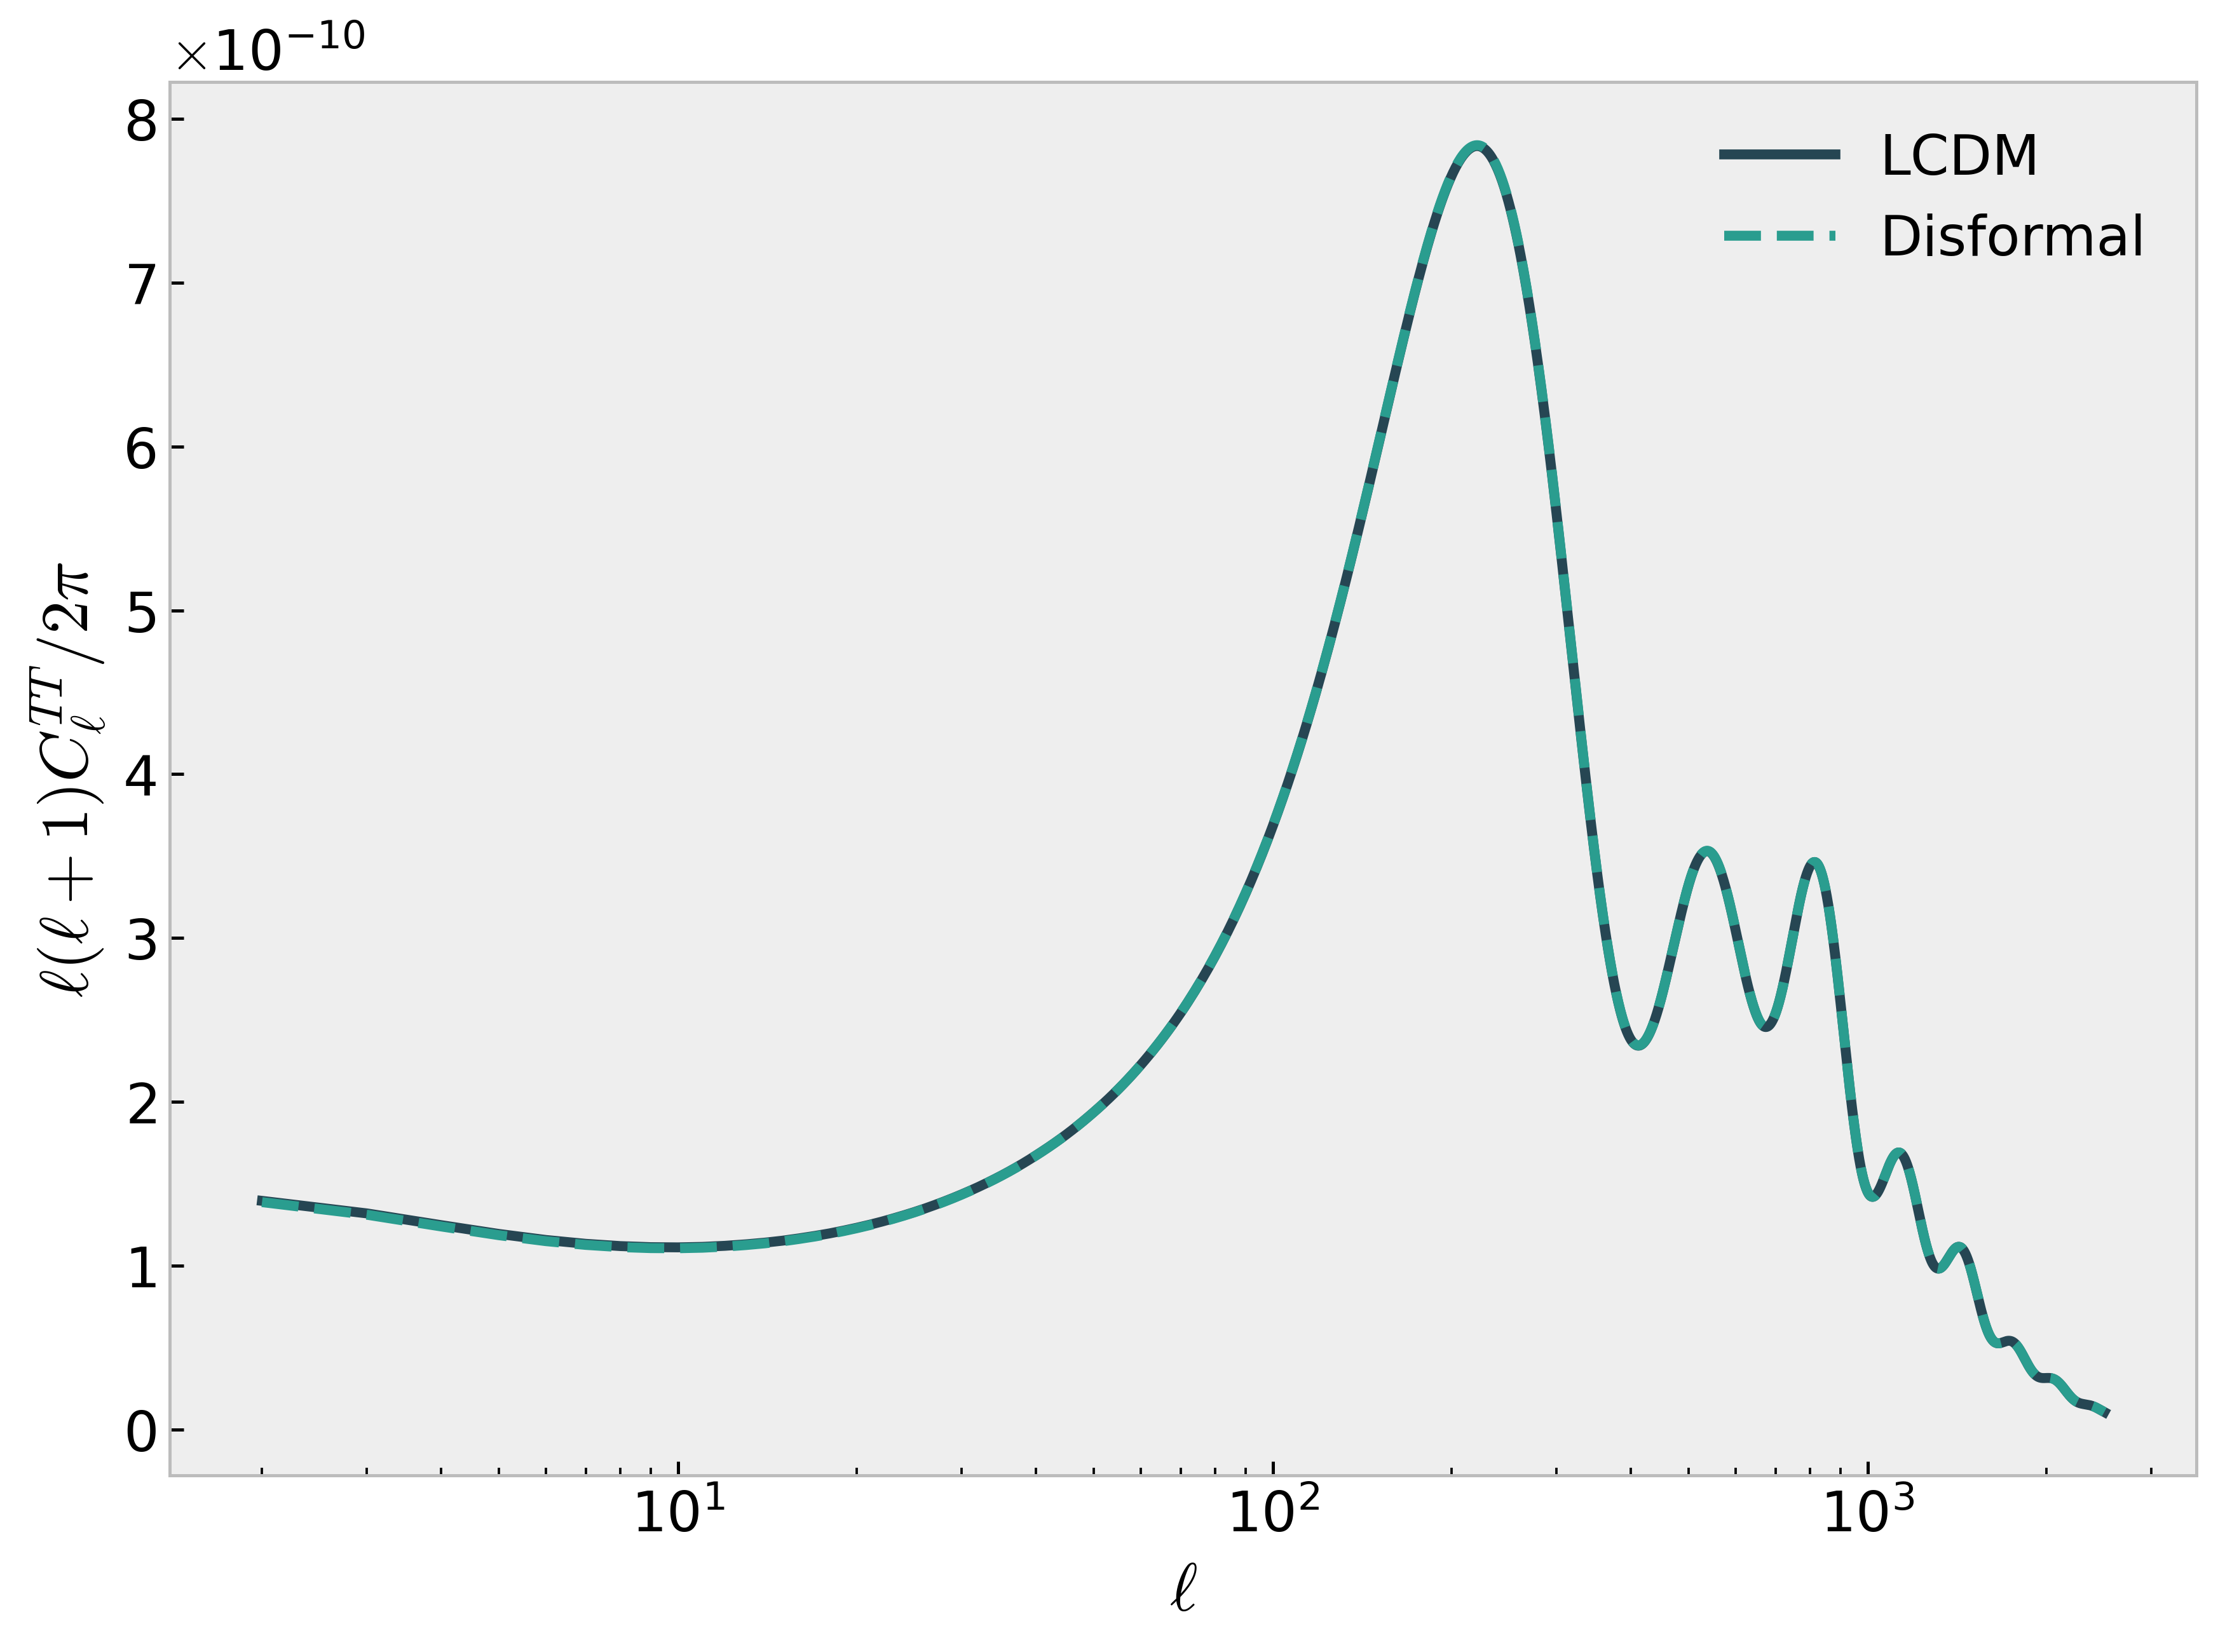

In [ ]:
# CMB TT spectrum (LCDM vs disformal)
cls_disf = disf.lensed_cl(2500)

ell = cls_lcdm['ell'][2:]
cltt_disf = cls_disf['tt'][2:]

plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.plot(ell, cltt_lcdm*ell*(ell+1)/(2*np.pi), lw=lw, ls='-', label='LCDM')
plt.plot(ell, cltt_disf*ell*(ell+1)/(2*np.pi), lw=lw, ls='--', label='Disformal')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$')
plt.legend()
plt.tight_layout()


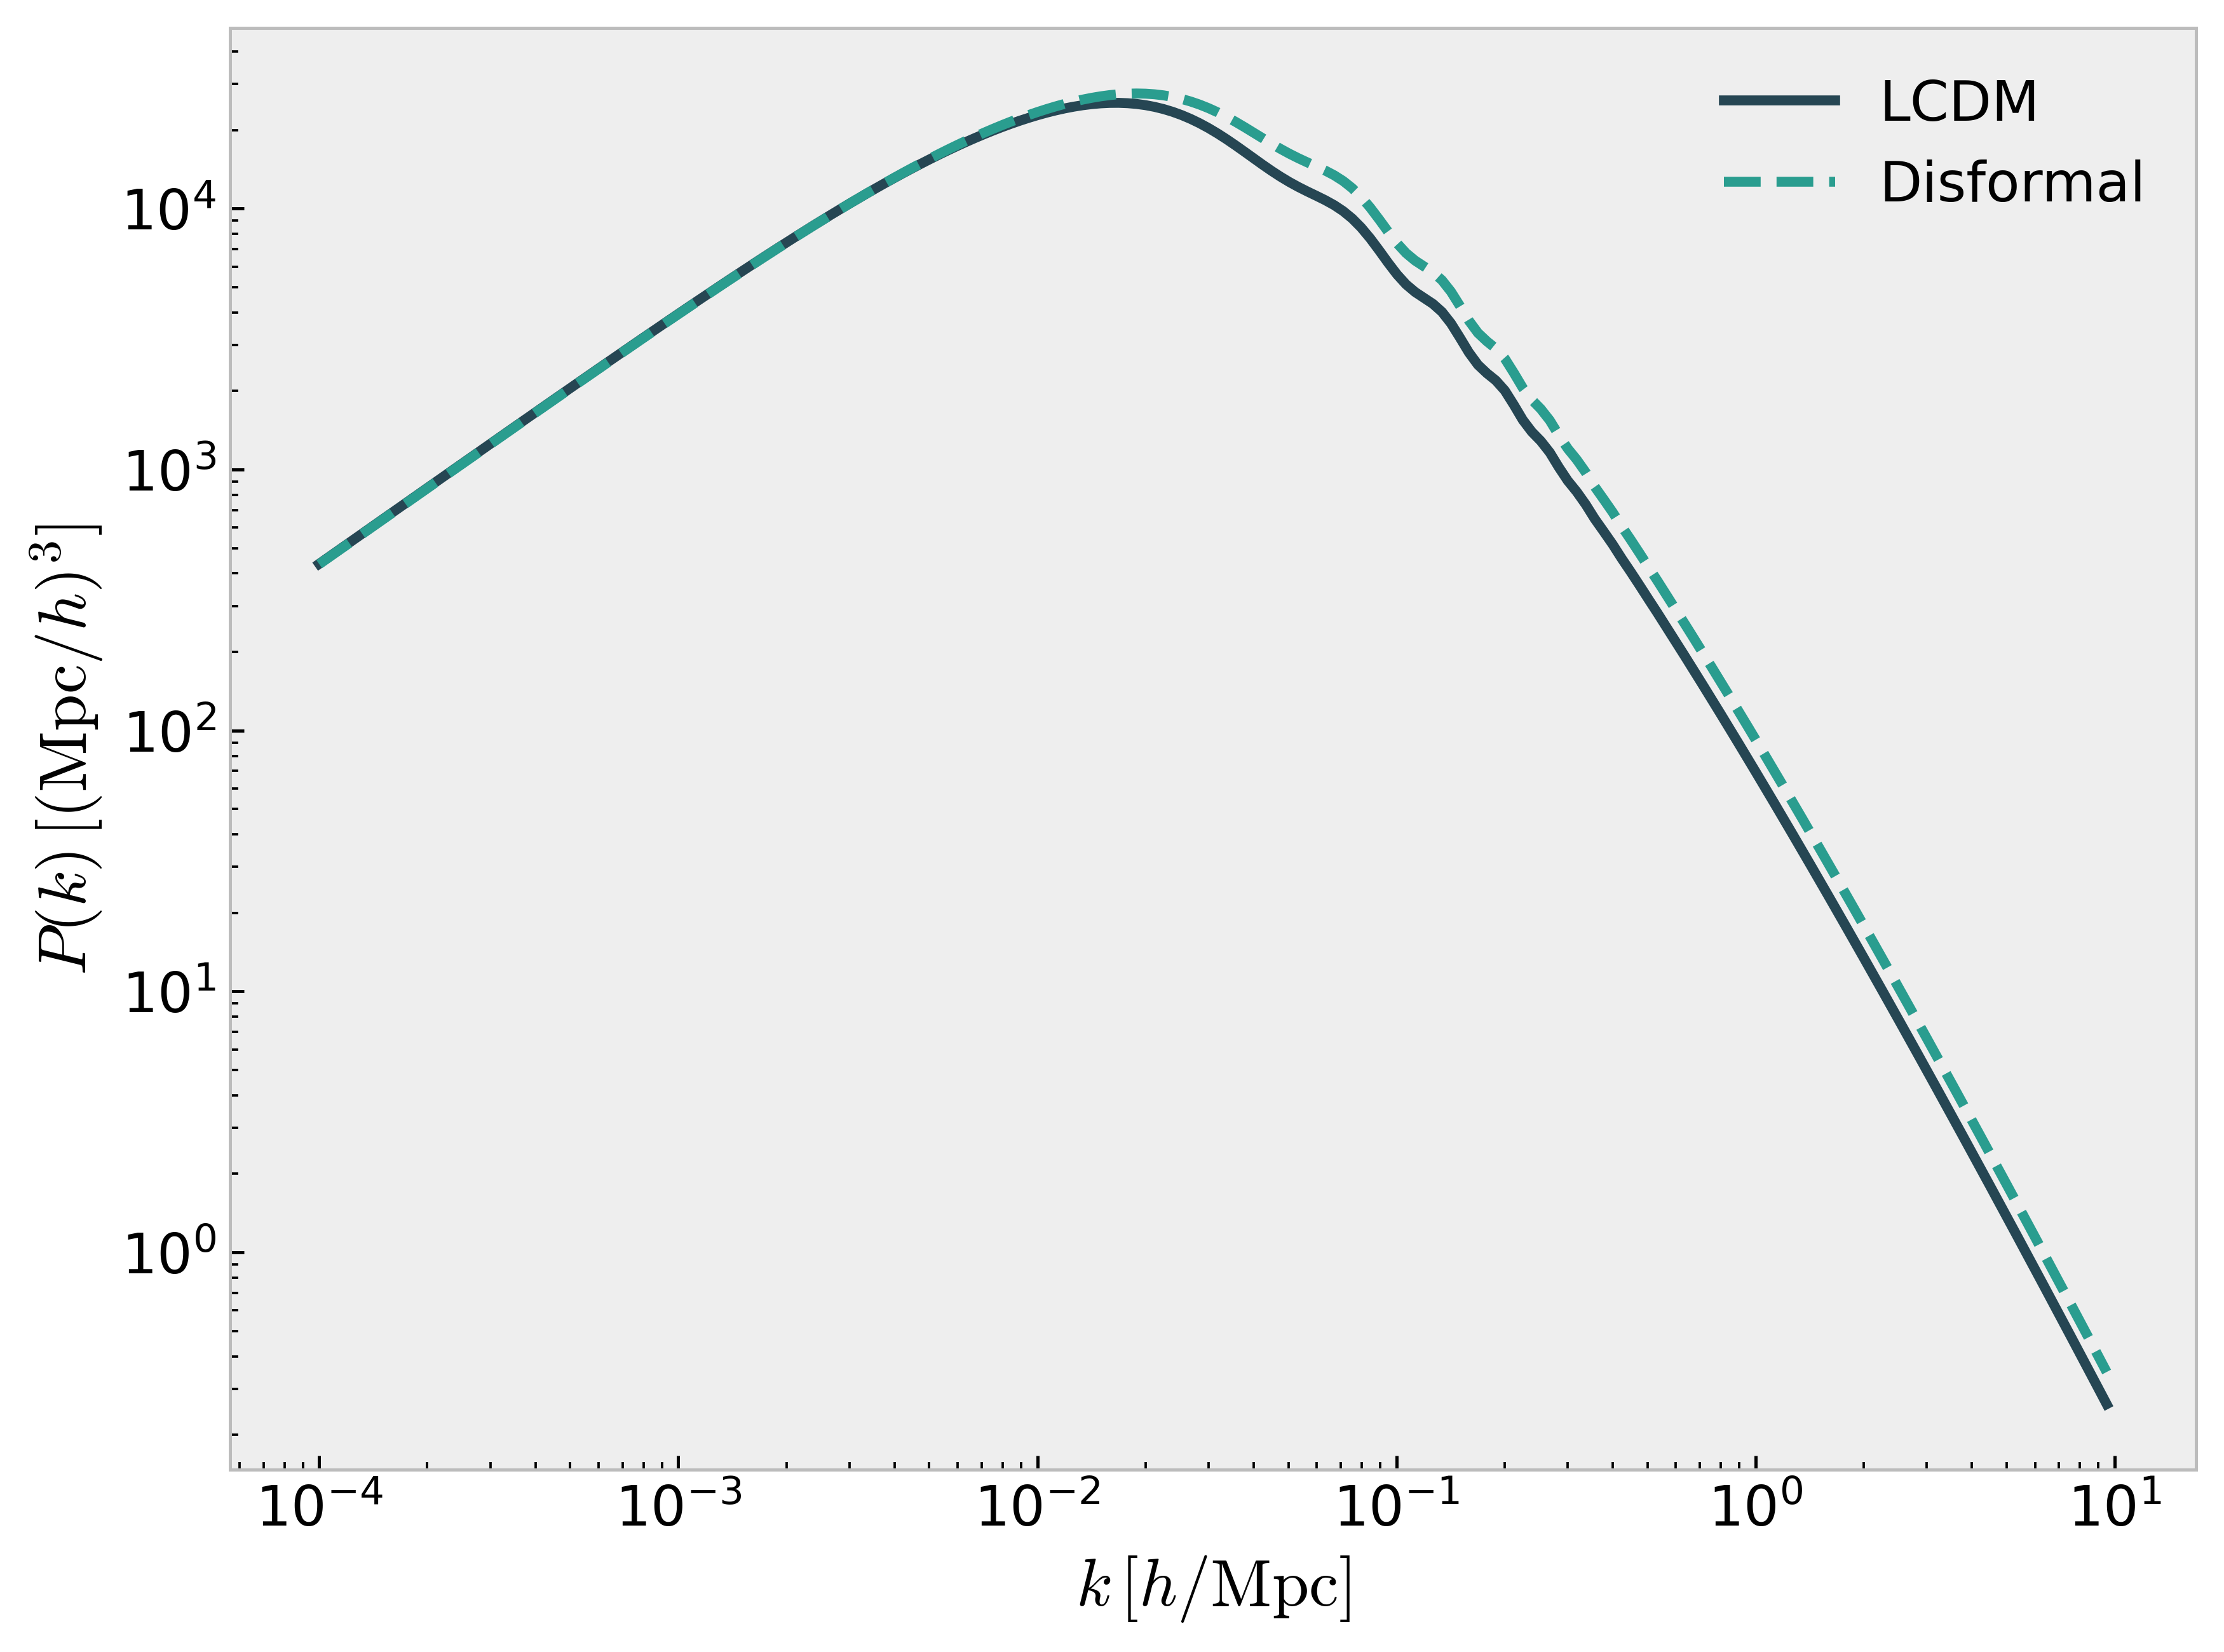

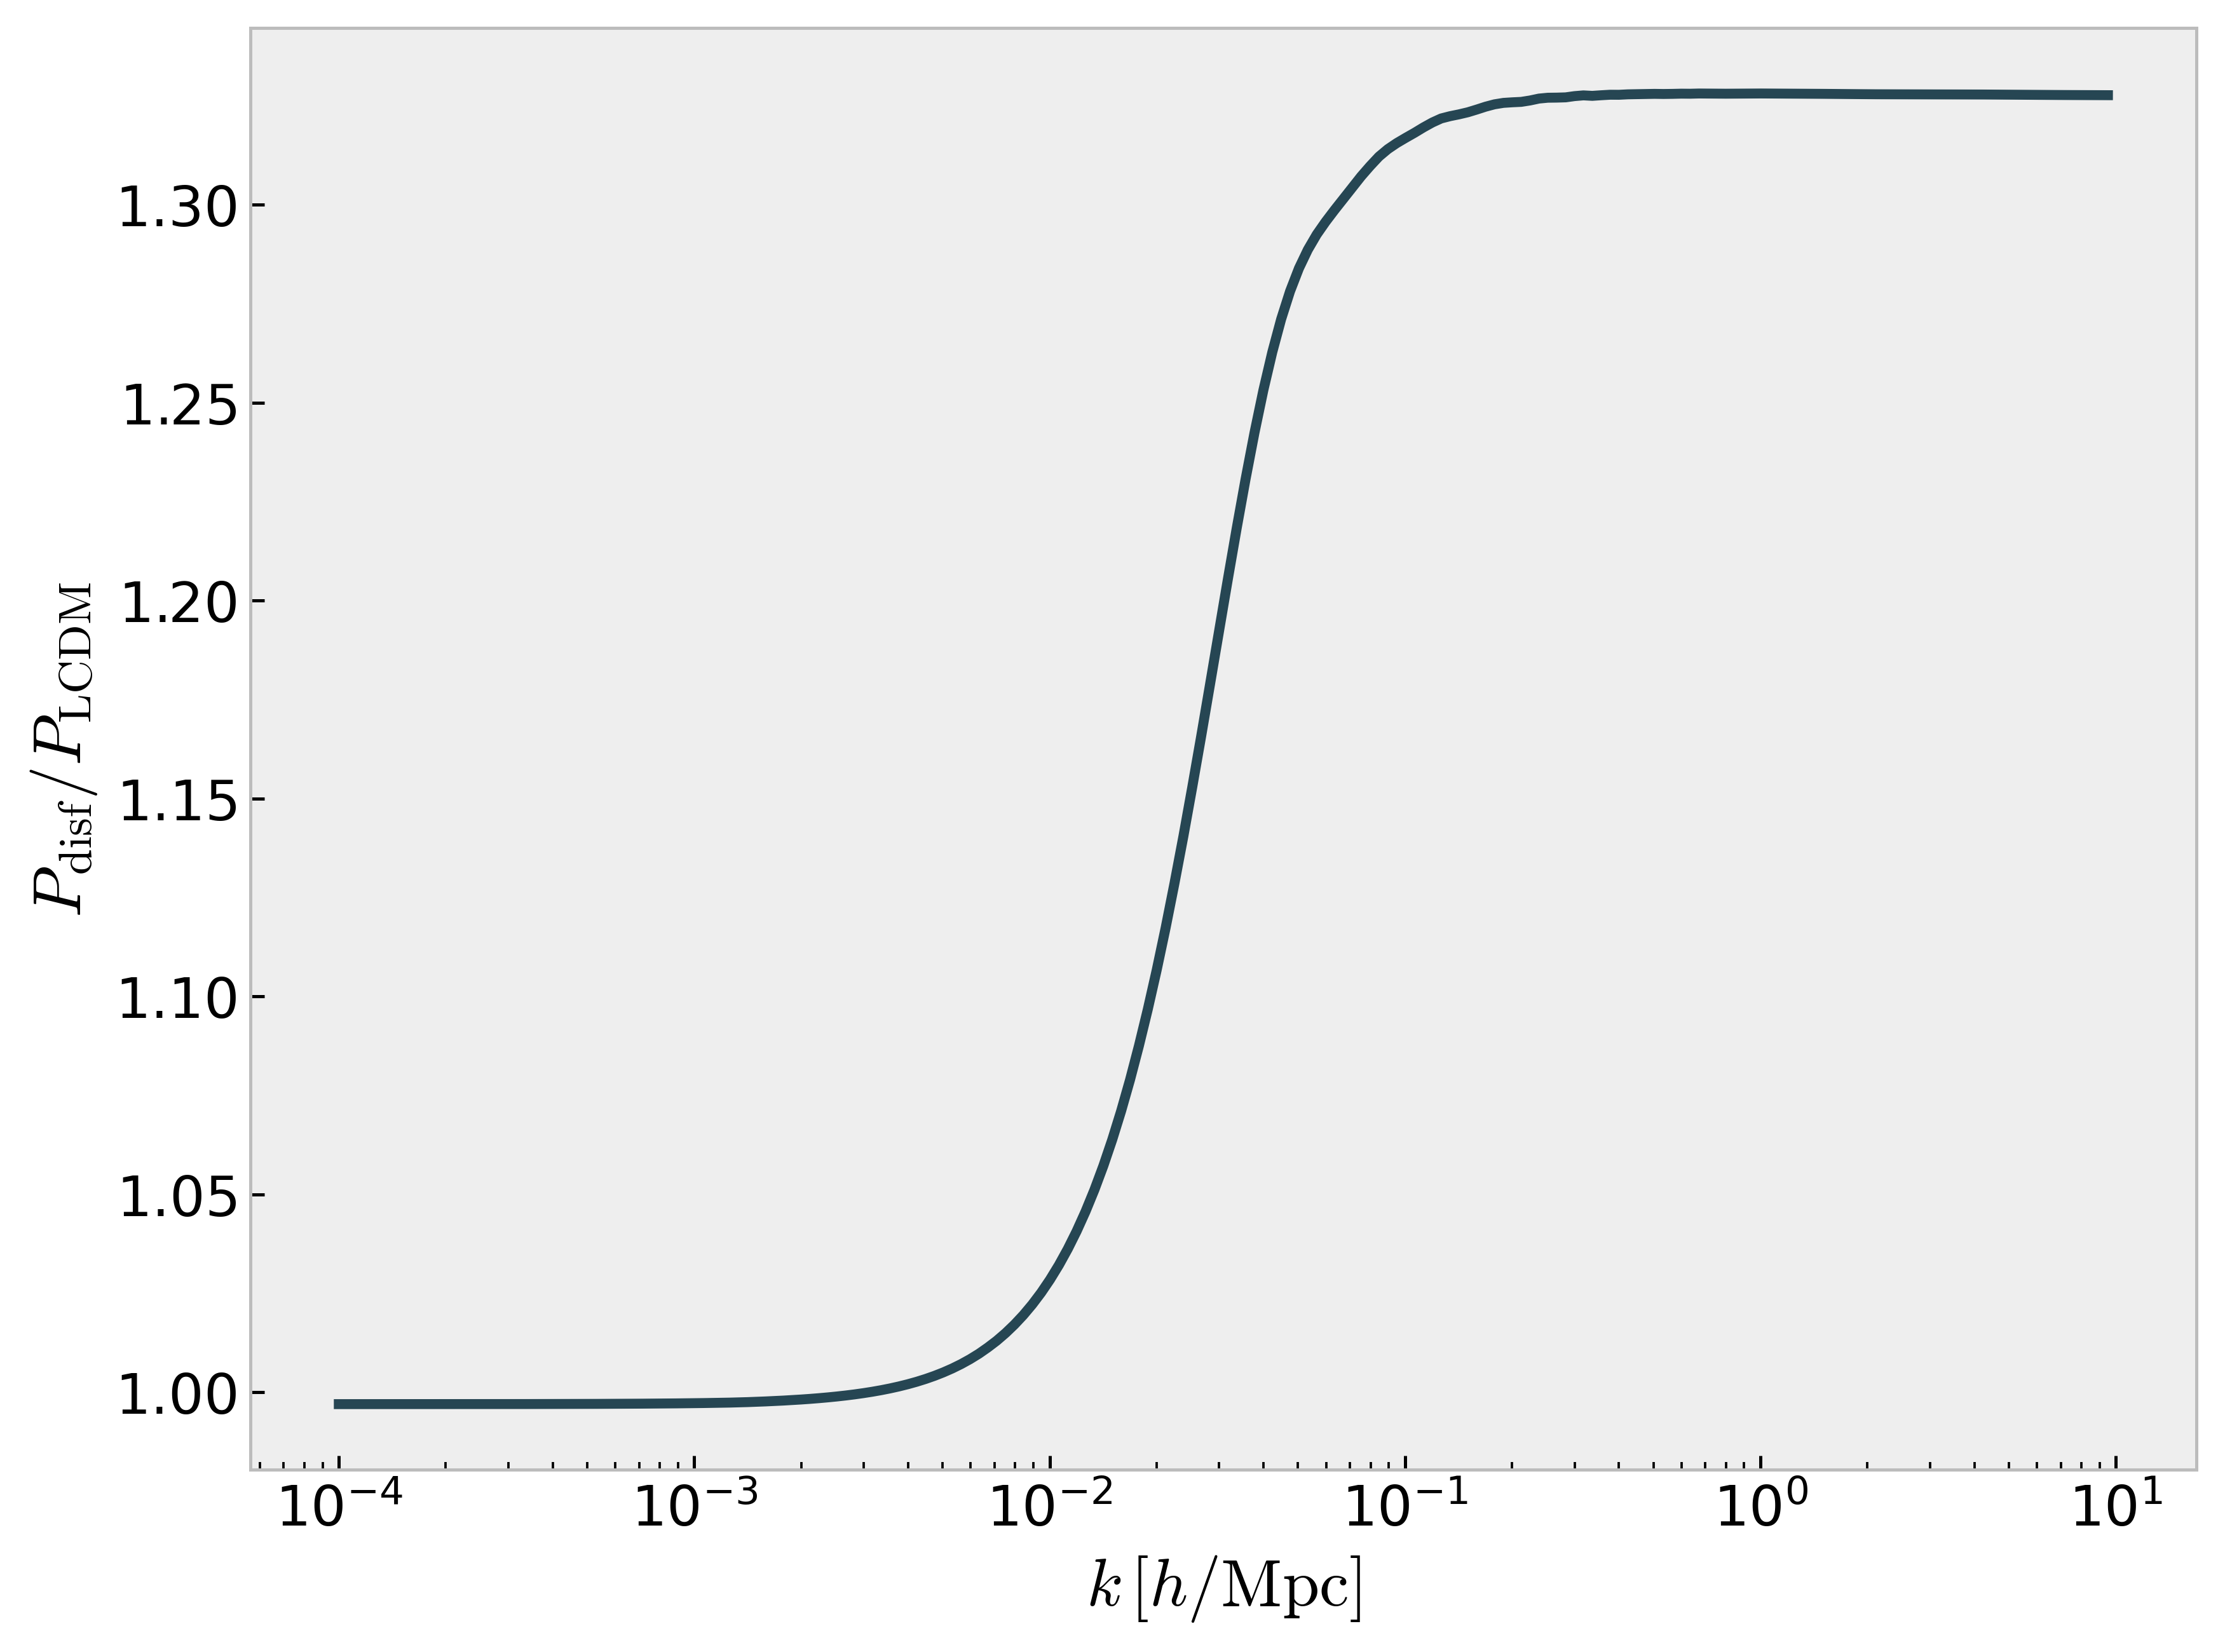

In [ ]:
# Matter power spectrum (LCDM vs disformal)
# k in h/Mpc, convert to 1/Mpc for CLASS
k_max = common['P_k_max_h/Mpc'] * 0.95
k = np.logspace(-4, np.log10(k_max), 200)
h = common['h']

pk_disf = np.array([disf.pk(ki*h, 0.0) * h**3 for ki in k])

plt.figure(figsize=(8, 6))
plt.loglog(k, pk_lcdm, lw=lw, ls='-', label='LCDM')
plt.loglog(k, pk_disf, lw=lw, ls='--', label='Disformal')
plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k)\,[\mathrm{(Mpc}/h)^3]$')
plt.legend()
plt.tight_layout()

# Ratio
plt.figure(figsize=(8, 6))
plt.semilogx(k, pk_disf/pk_lcdm, lw=lw, ls='-')
plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P_{\rm disf}/P_{\rm LCDM}$')
plt.tight_layout()


pert_disf type: <class 'dict'>
pert_disf keys: ['scalar']


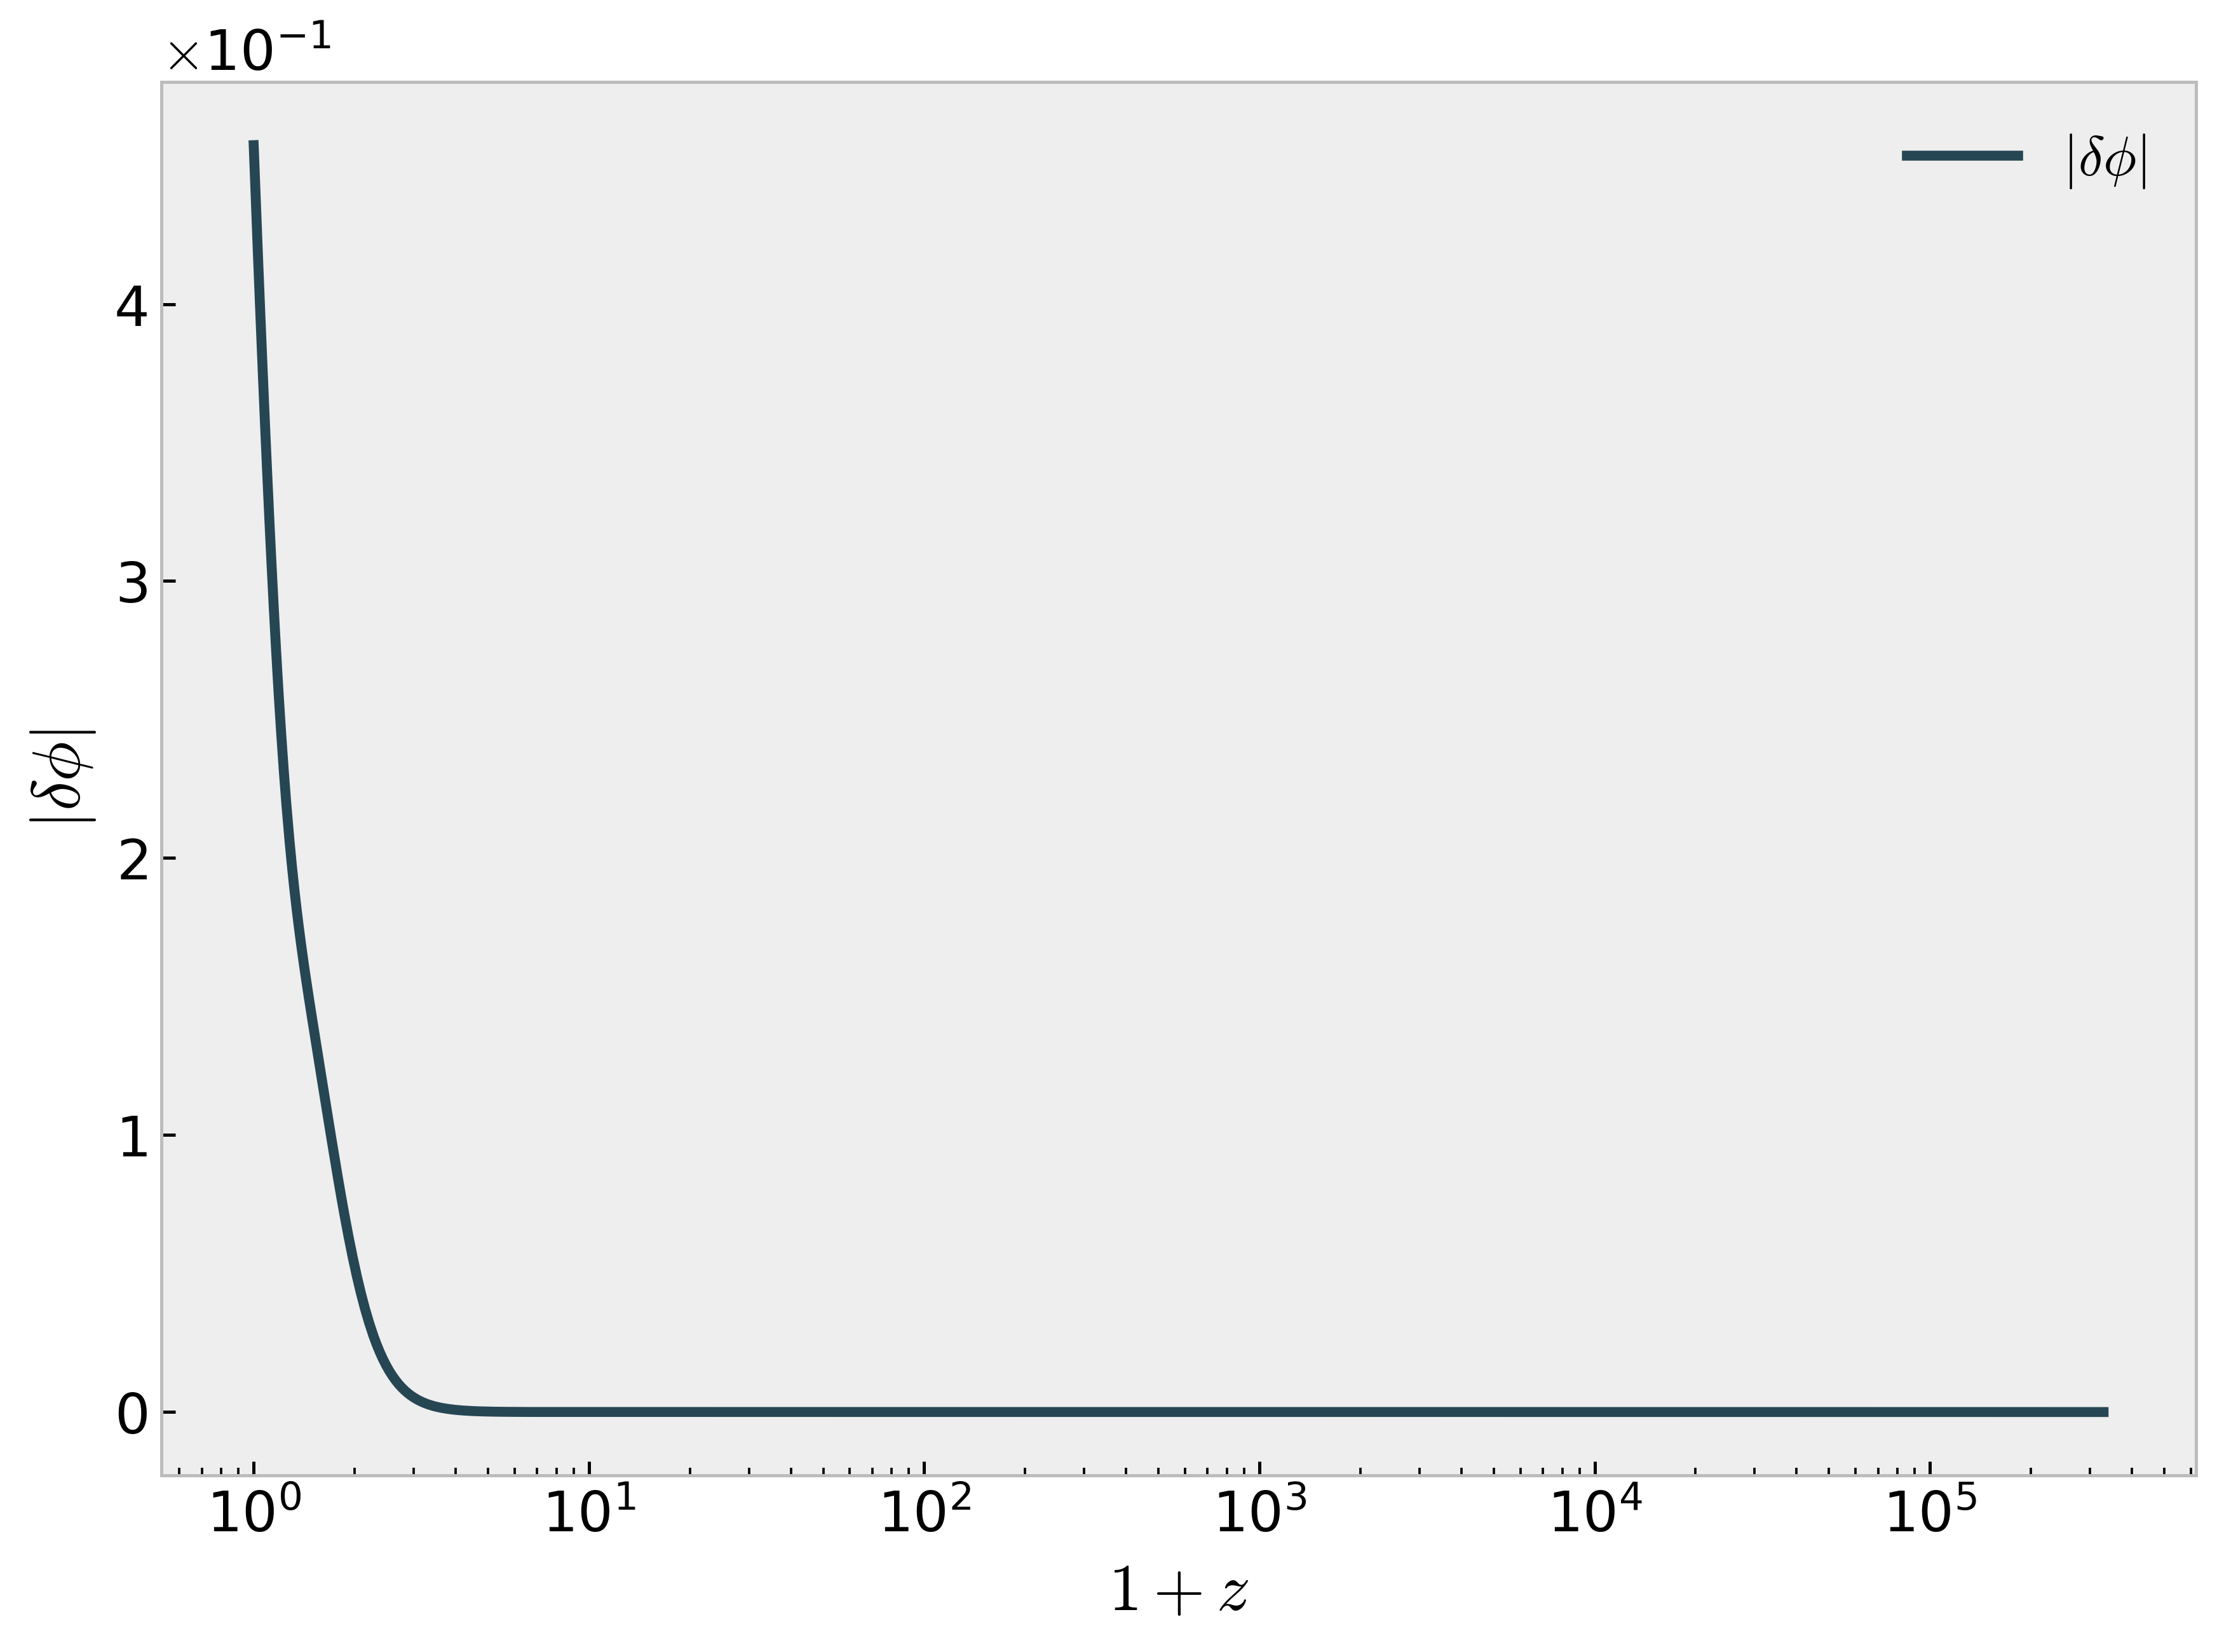

In [ ]:
pert_disf = disf.get_perturbations()

print('pert_disf type:', type(pert_disf))
if hasattr(pert_disf, 'keys'):
    print('pert_disf keys:', list(pert_disf.keys()))

p = None
if isinstance(pert_disf, dict):
    if 'scalar' in pert_disf:
        p = pert_disf['scalar'][0]
    elif 'scalars' in pert_disf:
        p = pert_disf['scalars'][0]
elif isinstance(pert_disf, list) and len(pert_disf) > 0:
    p = pert_disf[0]

if p is None:
    print('No scalar perturbations found. Set k_output_values to store perturbations.')
else:
    a = p['a']
    z = 1/a - 1

    plt.figure(figsize=(8, 6))
    if 'delta_phi_scf' in p:
        plt.semilogx(1+z, np.abs(p['delta_phi_scf']), lw=lw, label=r'$|\delta\phi|$')
        plt.xlabel(r'$1+z$')
        plt.ylabel(r'$|\delta\phi|$')
        plt.legend()
        plt.tight_layout()
    else:
        print('No delta_phi_scf field in perturbations output.')


## 8) Cleanup


In [ ]:
cleanup(lcdm)
cleanup(coup)
